<img src="https://res.cloudinary.com/dtizipxds/image/upload/q_auto/f_auto/v1776264397/banner_yvwajv.png" width="100%">


In [ ]:
%pip install -r ../requirements.txt

## Algerian Laptop Market - Feature Engineering & Data Cleaning

---

## Project Overview

This notebook presents a comprehensive data mining analysis of the Algerian laptop market dataset. Our primary objective is to **understand the data and business objectives, discover patterns, and extract actionable business insights** for both buyers and sellers.

### Methodology (CRISP-DM aligned)

| Phase | Content |
|-------|---------|
| **1** | Business Understanding — objectives for buyers and sellers |
| **2** | Data Understanding — load data, assess quality, initial EDA |
| **3** | **Data Preparation** (this notebook) — price cleaning, feature engineering (CPU, GPU, condition, etc.) |
| **4** | Modeling — train/test split, baseline models, regression |
| **5** | Evaluation — metrics, diagnostics, learning curves |
| **6** | Deployment — recommendations, pricing tool |

---

## Phase 1: Business Understanding

### Business Objectives

#### For Buyers:
1. **Value Maximization**: Find the best laptop configuration (CPU, GPU, RAM) for a given budget bracket (e.g., <80k, 80k–150k, >150k DZD)
2. **Price Optimization**: Identify fair market prices and quantify how much overpaying occurs (e.g., listings >20% above segment median)
3. **Feature Prioritization**: Understand which features justify premium pricing (e.g., +X% for High GPU vs None, +Y% for DDR5 vs DDR4)
4. **Condition Assessment**: Quantify the discount for used ("BON ÉTAT") vs. new ("JAMAIS UTILISÉ") laptops in % terms
5. **Timing Strategy**: Identify best months to buy (e.g., avoid back-to-school peaks in Aug–Oct when median prices may be higher)

#### For Sellers:
1. **Competitive Pricing**: Price laptops within ±10% of segment median to maximize sale probability
2. **Feature Highlighting**: Identify which features command the highest premiums (GPU tier, condition, brand) to emphasize in listings
3. **Condition Pricing**: Apply appropriate depreciation for used items (quantify "BON ÉTAT" discount vs "JAMAIS UTILISÉ")
4. **Timing Strategy**: Know when listing volume peaks (Aug–Oct) and whether median price rises or falls with volume
5. **Brand Positioning**: Understand brand premiums (e.g., Apple vs HP vs Lenovo for similar specs) to set competitive prices

---
**Authors**: Yassir CHERDOUH, Ahmed Fateh GUENDOUZ, Abdelhak KADOUCI, Abdennour SOUACI - Y3 G8

---
## 1. Setup and Environment Configuration

In [1]:
# ============================================================================
# IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import re
from scipy import stats
from scipy.stats import skew
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import scipy.stats as ss

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries imported successfully!")
print(f" Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All libraries imported successfully!
 Analysis started at: 2026-02-08 16:12:41


### 1.1 Define Custom Metrics

In [2]:
def mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error.

    Returns percentage error - useful for business interpretation.
    Example: MAPE of 15% means predictions are off by 15% on average.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print("Custom MAPE function defined")


### 1.2 Load Dataset

In [3]:
# Load raw data
df = pd.read_csv('../data/data.csv')

# Create working copy
df_clean = df.copy()

print(f"Dataset loaded successfully!")
print(f" Total records: {len(df_clean):,}")
print(f" Total columns: {len(df_clean.columns)}")

Dataset loaded successfully!
 Total records: 16,406
 Total columns: 14


#### Initial Data Snapshot (Raw)

Before any cleaning, we visualize **raw price distribution** and **missing values** to understand data quality. Prices are often right-skewed and may contain typos (e.g. missing zeros or centimes confusion); the following cleaning steps address these.

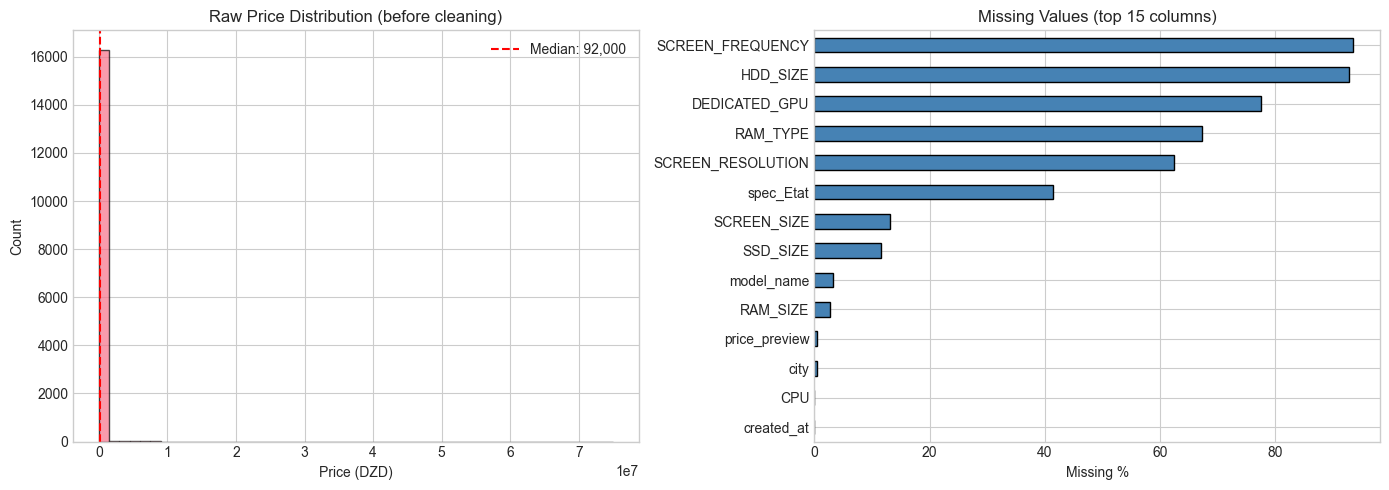

Raw price skewness: 73.44 (right-skewed if > 1)


In [4]:
# Raw price distribution and missing values (before cleaning)
price_raw = df_clean['price_preview'].dropna()
price_raw = price_raw[price_raw > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(price_raw, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(price_raw.median(), color='red', linestyle='--', label=f'Median: {price_raw.median():,.0f}')
axes[0].set_xlabel('Price (DZD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Price Distribution (before cleaning)')
axes[0].legend()

missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=True).tail(15)
missing_pct.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Values (top 15 columns)')
plt.tight_layout()
plt.show()
print(f"Raw price skewness: {skew(price_raw):.2f} (right-skewed if > 1)")

# Store initial stats for before/after cleaning summary (no target used in cleaning)
stats_before = {
'n': len(df_clean),
'price_median': float(price_raw.median()),
'price_q25': float(price_raw.quantile(0.25)),
'price_q75': float(price_raw.quantile(0.75)),
'skew': float(skew(price_raw))
}

**Takeaway:** Raw prices are right-skewed and missing values exist; this justifies the upcoming cleaning steps (invalid removal, currency fix, IQR) and the use of robust metrics or log-scale in later modeling.

---
## 2.  Feature Engineering

### 2.1 Temporal Feature Engineering

In [5]:
# ============================================================================
# TEMPORAL FEATURE EXTRACTION
# ============================================================================

print("=" * 80)
print("TEMPORAL FEATURE EXTRACTION")
print("=" * 80)

# Parse datetime and extract components
df_clean['created_at_parsed'] = pd.to_datetime(df_clean['created_at'], errors='coerce')
df_clean['listing_year'] = df_clean['created_at_parsed'].dt.year
df_clean['listing_month'] = df_clean['created_at_parsed'].dt.month

# Back-to-school season flag (August, September, October)
df_clean['back_to_school'] = df_clean['listing_month'].isin([8, 9, 10]).astype(int)

# Ordinal date for time-series modeling
df_clean['listing_date_ordinal'] = df_clean['created_at_parsed'].apply(
lambda x: x.toordinal() if pd.notna(x) else np.nan
)

print(f"Temporal features created: listing_year, listing_month, back_to_school")
print(f" Date range: {df_clean['created_at_parsed'].min()} to {df_clean['created_at_parsed'].max()}")

TEMPORAL FEATURE EXTRACTION
Temporal features created: listing_year, listing_month, back_to_school
 Date range: 2018-11-27 08:27:31+00:00 to 2025-08-11 16:34:50+00:00


---
### 2.2 Brand and Series Extraction

In [6]:
# ============================================================================
# BRAND AND SERIES EXTRACTION (EXPANDED & COMPREHENSIVE)
# ============================================================================

print("=" * 80)
print("BRAND AND SERIES EXTRACTION")
print("=" * 80)

# 1. EXPANDED BRAND MAP (Handles Parent Brands & Unique Sub-brands)
brand_map = {
'LENOVO': ['LENOVO', 'THINKPAD', 'IDEAPAD', 'LEGION', 'YOGA', 'THINKBOOK', 'LOQ'],
'HP': ['HP', 'PAVILION', 'OMEN', 'ELITEBOOK', 'PROBOOK', 'ENVY', 'SPECTRE', 'ZBOOK', 'VICTUS', 'DRAGONFLY', 'CHROMEBOOK'],
'DELL': ['DELL', 'XPS', 'LATITUDE', 'INSPIRON', 'ALIENWARE', 'PRECISION', 'VOSTRO', 'G15', 'G16'],
'ASUS': ['ASUS', 'ROG', 'TUF', 'VIVOBOOK', 'ZENBOOK', 'STRIX', 'EXPERTBOOK', 'ZEPHYRUS', 'PROART', 'FLOW'],
'ACER': ['ACER', 'ASPIRE', 'PREDATOR', 'NITRO', 'SWIFT', 'SPIN', 'TRAVELMATE', 'CONCEPTD', 'EXTENSA', 'ENDURO'],
'MSI': ['MSI', 'STEALTH', 'RAIDER', 'KATANA', 'SWORD', 'VECTOR', 'BRAVO', 'TITAN', 'CYBORG', 'PULSE', 'CROSSHAIR', 'DELTA', 'ALPHA', 'SUMMIT', 'PRESTIGE', 'MODERN', 'CREATOR'],
'APPLE': ['APPLE', 'MACBOOK', 'MAC'],
'MICROSOFT': ['MICROSOFT', 'SURFACE'],
'RAZER': ['RAZER', 'BLADE'],
'SAMSUNG': ['SAMSUNG', 'GALAXY BOOK', 'ODYSSEY'],
'HUAWEI': ['HUAWEI', 'MATEBOOK'],
'LG': ['LG', 'GRAM'],
'GIGABYTE': ['GIGABYTE', 'AORUS', 'AERO'],
'GOOGLE': ['GOOGLE', 'PIXELBOOK'],
}

print(f" Defined {len(brand_map)} brand categories with keywords")

BRAND AND SERIES EXTRACTION
 Defined 14 brand categories with keywords


In [7]:
# 2. COMPREHENSIVE SERIES LIST
known_series_list = [
# --- APPLE ---
'MACBOOK PRO', 'MACBOOK AIR', 'MACBOOK',
# --- MICROSOFT ---
'SURFACE LAPTOP STUDIO', 'SURFACE LAPTOP GO', 'SURFACE LAPTOP',
'SURFACE BOOK', 'SURFACE PRO', 'SURFACE GO', 'SURFACE STUDIO',
# --- RAZER ---
'BLADE STEALTH', 'BLADE PRO', 'BLADE 14', 'BLADE 15', 'BLADE 16', 'BLADE 17', 'BLADE 18', 'BLADE',
# --- LENOVO ---
'THINKPAD X1', 'THINKPAD', 'THINKBOOK', 'IDEAPAD GAMING', 'IDEAPAD',
'LEGION PRO', 'LEGION SLIM', 'LEGION', 'LOQ', 'YOGA SLIM', 'YOGA BOOK', 'YOGA',
# --- HP ---
'ELITEBOOK DRAGONFLY', 'ELITEBOOK', 'PROBOOK', 'ZBOOK FIREFLY', 'ZBOOK FURY', 'ZBOOK POWER', 'ZBOOK STUDIO', 'ZBOOK',
'SPECTRE X360', 'SPECTRE', 'ENVY X360', 'ENVY', 'OMEN', 'VICTUS', 'PAVILION AERO', 'PAVILION GAMING', 'PAVILION', 'STREAM',
# --- DELL ---
'ALIENWARE X', 'ALIENWARE M', 'ALIENWARE AREA-51M', 'ALIENWARE',
'PRECISION', 'LATITUDE', 'XPS 13', 'XPS 15', 'XPS 17', 'XPS', 'INSPIRON', 'VOSTRO', 'DELL G3', 'DELL G5', 'DELL G7', 'DELL G15', 'DELL G16',
# --- ASUS ---
'ROG ZEPHYRUS', 'ROG STRIX', 'ROG FLOW', 'ROG SCAR', 'ROG',
'TUF DASH', 'TUF GAMING', 'TUF', 'ZENBOOK DUO', 'ZENBOOK PRO', 'ZENBOOK FLIP', 'ZENBOOK',
'VIVOBOOK PRO', 'VIVOBOOK FLIP', 'VIVOBOOK S', 'VIVOBOOK', 'EXPERTBOOK', 'PROART STUDIOBOOK', 'PROART',
# --- ACER ---
'PREDATOR TRITON', 'PREDATOR HELIOS', 'PREDATOR', 'NITRO 5', 'NITRO 16', 'NITRO 17', 'NITRO',
'SWIFT GO', 'SWIFT EDGE', 'SWIFT X', 'SWIFT', 'SPIN', 'ASPIRE VERO', 'ASPIRE', 'TRAVELMATE', 'CONCEPTD', 'EXTENSA',
# --- MSI ---
'TITAN GT', 'RAIDER GE', 'STEALTH GS', 'VECTOR GP', 'CROSSHAIR', 'PULSE', 'KATANA', 'SWORD', 'CYBORG', 'THIN GF',
'DELTA', 'ALPHA', 'BRAVO', 'CREATOR PRO', 'CREATOR', 'SUMMIT', 'PRESTIGE', 'MODERN',
# --- OTHERS ---
'MATEBOOK X PRO', 'MATEBOOK D', 'MATEBOOK E', 'MATEBOOK', 'LG GRAM', 'GRAM',
'GALAXY BOOK PRO', 'GALAXY BOOK', 'ODYSSEY', 'AORUS', 'AERO', 'PIXELBOOK GO', 'PIXELBOOK'
]

# CRITICAL: Sort by length (descending) so "MacBook Pro" matches before "MacBook"
known_series_list.sort(key=len, reverse=True)

print(f" Defined {len(known_series_list)} known product series")

 Defined 132 known product series


In [8]:
# 3. DEFINE GAMING SERIES AND BUILD QUALITY TIER MAP
GAMING_SERIES = [
'ROG', 'TUF', 'STRIX', 'LEGION', 'OMEN', 'VICTUS', 'PREDATOR', 'NITRO', 'ALIENWARE',
'RAIDER', 'STEALTH', 'KATANA', 'SWORD', 'VECTOR', 'TITAN', 'CYBORG', 'PULSE', 'CROSSHAIR',
'THIN GF', 'ALPHA', 'BRAVO', 'DELTA', 'LOQ', 'IDEAPAD GAMING', 'PAVILION GAMING',
'DELL G3', 'DELL G5', 'DELL G7', 'DELL G15', 'DELL G16', 'BLADE', 'AORUS', 'ODYSSEY'
]

# BUILD QUALITY TIER MAP (1-5 scale by series)
# 1 = Budget, 2 = Consumer, 3 = Business, 4 = Premium, 5 = Workstation/Gaming Flagship
series_tier_map = {
# HP
'STREAM': 1, # Budget
'PAVILION': 2, # Consumer
'PROBOOK': 3, # Business
'ELITEBOOK': 4, # Premium business
'ENVY': 4, # Premium consumer
'SPECTRE': 5, # Ultra premium
'ZBOOK': 5, # Workstation
'OMEN': 5, # Gaming flagship
'VICTUS': 4, # Gaming mid-range

# Dell
'INSPIRON': 2, # Consumer
'VOSTRO': 3, # Small business
'LATITUDE': 4, # Enterprise
'XPS': 5, # Premium consumer
'PRECISION': 5, # Workstation
'ALIENWARE': 5, # Gaming flagship
'DELL G': 4, # Gaming mid-range

# Lenovo
'IDEAPAD': 2, # Consumer
'THINKBOOK': 3, # SMB
'THINKPAD': 4, # Enterprise
'YOGA': 4, # Premium convertible
'LEGION': 5, # Gaming flagship
'LOQ': 3, # Gaming entry

# ASUS
'VIVOBOOK': 2, # Consumer
'EXPERTBOOK': 3, # Business
'ZENBOOK': 4, # Premium
'PROART': 5, # Creator workstation
'ROG': 5, # Gaming flagship
'TUF': 4, # Gaming durable
'STRIX': 5, # Gaming premium

# Acer
'ASPIRE': 2, # Consumer
'SPIN': 3, # Convertible
'SWIFT': 4, # Premium ultrabook
'PREDATOR': 5, # Gaming flagship
'NITRO': 4, # Gaming mid-range
'TRAVELMATE': 3, # Business
'CONCEPTD': 5, # Creator

# MSI
'MODERN': 2, # Consumer
'PRESTIGE': 4, # Premium
'CREATOR': 5, # Creator workstation
'STEALTH': 5, # Gaming premium thin
'RAIDER': 5, # Gaming flagship
'KATANA': 4, # Gaming mid-range
'TITAN': 5, # Gaming ultimate
'CYBORG': 3, # Gaming entry

# Apple
'MACBOOK AIR': 4, # Premium consumer
'MACBOOK PRO': 5, # Professional
'MACBOOK': 4, # Generic MacBook

# Toshiba/Dynabook
'SATELLITE': 2, # Consumer
'TECRA': 3, # Business
'PORTEGE': 4, # Premium business

# Samsung
'GALAXY BOOK': 4, # Premium

# Huawei
'MATEBOOK': 4, # Premium
}

def extract_brand_and_series(model_name):
    """Extract brand, series, and build quality tier from laptop model name."""
    result = {'brand': 'OTHER', 'series': 'UNKNOWN', 'build_quality_tier': 2} # Default tier 2 (consumer)

    if pd.isna(model_name):
        return result

    model_upper = str(model_name).upper()

    # A. Extract Brand
    for brand, keywords in brand_map.items():
        for kw in keywords:
            if kw in model_upper:
                result['brand'] = brand
                break
        if result['brand'] != 'OTHER':
            break

    # B. Extract Series and Build Quality Tier (First match is most specific due to length-sorting)
    for series in known_series_list:
        if series in model_upper:
            result['series'] = series
            # Get build quality tier from map (default 2 if not found)
            result['build_quality_tier'] = series_tier_map.get(series, 2)
            break

    # Apple default to tier 4 even if series not matched
    if result['brand'] == 'APPLE' and result['build_quality_tier'] == 2:
        result['build_quality_tier'] = 4

    return result

print("Gaming series, build quality tier map, and extraction function defined")
print(f" Series tier mappings: {len(series_tier_map)}")


Gaming series, build quality tier map, and extraction function defined
 Series tier mappings: 52


In [9]:
# Apply Brand, Series, and Build Quality Tier Extraction
brand_series_features = df_clean['model_name'].apply(extract_brand_and_series)
df_clean['brand'] = brand_series_features.apply(lambda x: x['brand'])
df_clean['series'] = brand_series_features.apply(lambda x: x['series'])
df_clean['build_quality_tier'] = brand_series_features.apply(lambda x: x['build_quality_tier'])

# Gaming Flag - Check if any keyword from GAMING_SERIES is in the extracted series
df_clean['is_gaming_series'] = df_clean['series'].apply(
lambda s: 1 if any(g in s for g in GAMING_SERIES) else 0
)

# Verification
print(f"\n Brand Distribution:")
print(f" Unique brands: {df_clean['brand'].nunique()}")
print(df_clean['brand'].value_counts().head(10))

print(f"\n Series Distribution:")
print(f" Unique series: {df_clean['series'].nunique()}")
print(df_clean['series'].value_counts().head(10))

print(f"\n Build Quality Tier Distribution:")
tier_labels = {1: 'Budget', 2: 'Consumer', 3: 'Business', 4: 'Premium', 5: 'Workstation/Gaming'}
tier_counts = df_clean['build_quality_tier'].value_counts().sort_index()
for tier, count in tier_counts.items():
    pct = count / len(df_clean) * 100
    print(f" Tier {tier} ({tier_labels.get(tier, 'Unknown')}): {count:,} ({pct:.1f}%)")

    print(f"\n Gaming laptops identified: {df_clean['is_gaming_series'].sum()} ({df_clean['is_gaming_series'].mean()*100:.1f}%)")



 Brand Distribution:
 Unique brands: 11
brand
DELL         3773
HP           3766
LENOVO       3346
APPLE        1758
ASUS         1379
OTHER         805
ACER          673
MICROSOFT     499
MSI           344
GIGABYTE       33
Name: count, dtype: int64

 Series Distribution:
 Unique series: 35
series
THINKPAD     2403
LATITUDE     2334
UNKNOWN      1682
MACBOOK      1664
ELITEBOOK    1132
PAVILION     1126
VIVOBOOK      787
PROBOOK       737
INSPIRON      656
IDEAPAD       482
Name: count, dtype: int64

 Build Quality Tier Distribution:
 Tier 2 (Consumer): 5,049 (30.8%)

 Gaming laptops identified: 1387 (8.5%)
 Tier 3 (Business): 1,113 (6.8%)

 Gaming laptops identified: 1387 (8.5%)
 Tier 4 (Premium): 8,810 (53.7%)

 Gaming laptops identified: 1387 (8.5%)
 Tier 5 (Workstation/Gaming): 1,434 (8.7%)

 Gaming laptops identified: 1387 (8.5%)


---
### 2.3 Wilaya Extraction

In [10]:
import pandas as pd

# Dictionary mapping Commune/Locality ->

city_to_wilaya_map = {
# --- WILAYA DE ALGER (16) ---
'EZZOUAR': 'Alger', # Likely Bab Ezzouar
'ALGER CENTRE': 'Alger',
'KOUBA': 'Alger',
'AIN NAADJA': 'Alger', # Locality in Gue de Constantine
'BIRKHADEM': 'Alger',
'HUSSEIN DEY': 'Alger',
'DELY BRAHIM': 'Alger',
'DAR EL BEIDA': 'Alger',
'MOHAMMADIA': 'Alger',
'BORDJ EL KIFFAN': 'Alger',
'DRARIA': 'Alger',
'ZERALDA': 'Alger',
'HYDRA': 'Alger',
'EL HARRACH': 'Alger',
'CHERAGA': 'Alger',
'OULED FAYET': 'Alger',
'BABA HASSEN': 'Alger',
'BIRTOUTA': 'Alger',
'DOUERA': 'Alger',
'EL ACHOUR': 'Alger',
'REGHAIA': 'Alger',
'AIN BENIAN': 'Alger',
'BACHDJERRAH': 'Alger',
'EL BIAR': 'Alger',
'BORDJ EL BAHRI': 'Alger',
'BIR MOURAD RAIS': 'Alger',
'BOUZAREAH': 'Alger',
'ROUIBA': 'Alger',
'LES EUCALYPTUS': 'Alger',
'BEN AKNOUN': 'Alger',
'BARAKI': 'Alger',
'OUED SMAR': 'Alger',
'SAID HAMDINE': 'Alger', # Locality in Bir Mourad Rais
'AIN TAYA': 'Alger',
'STAOUELI': 'Alger',
'SOUIDANIA': 'Alger',
'MAHELMA': 'Alger',
'BENI MESSOUS': 'Alger',
'HRAOUA': 'Alger',
'CHEVALLEY': 'Alger', # Locality
'SAOULA': 'Alger',
'GUE DE CONSTANTINE': 'Alger',
'EL MOURADIA': 'Alger',
'SIDI MHAMED': 'Alger', # Assuming Alger (common), though exists in Msila
'KHRAISSIA': 'Alger',
'SIDI MOUSSA': 'Alger',
'RAHMANIA': 'Alger',
'BOLOGHINE': 'Alger',
'EL MADANIA': 'Alger',
'CASBAH': 'Alger',
'RAIS HAMIDOU': 'Alger',
'TESALLA EL MERDJA': 'Alger',
'OULED CHEBEL': 'Alger',
'TESSALA EL MERDJA': 'Alger',

# --- WILAYA DE ORAN (31) ---
'ORAN': 'Oran',
'BIR EL DJIR': 'Oran',
'ES SENIA': 'Oran',
'AIN EL TURCK': 'Oran',
'ARZEW': 'Oran',
'GDYEL': 'Oran',
'MISSEGHINE': 'Oran',
'MERS EL KBIR': 'Oran',
'BOUTLELIS': 'Oran',
'BETHIOUA': 'Oran',
'SIDI CHAMI': 'Oran',
'EL KERMA': 'Oran',
'HASSI BEN OKBA': 'Oran',

# --- WILAYA DE BLIDA (09) ---
'BLIDA': 'Blida',
'BOUFARIK': 'Blida',
'OULED YAICH': 'Blida',
'BENI MERED': 'Blida',
'BOUINAN': 'Blida',
'MEFTAH': 'Blida',
'BOUARFA': 'Blida',
'MOUZAIA': 'Blida',
'EL AFFROUN': 'Blida',
'CHEBLI': 'Blida',
'OULED EL ALLEUG': 'Blida',
'CHIFFA': 'Blida',
'SOUMAA': 'Blida',
'BOUGARA': 'Blida',
'AIN ROMANA': 'Blida',

# --- WILAYA DE SETIF (19) ---
'SETIF': 'Setif',
'EL EULMA': 'Setif',
'AIN OULMENE': 'Setif',
'AIN AZEL': 'Setif',
'AIN ARNAT': 'Setif',
'AIN EL KEBIRA': 'Setif',
'SALAH BEY': 'Setif',
'BOUGAA': 'Setif',
'AIN ABESSA': 'Setif',
'BENI OUARTILENE': 'Setif',

# --- WILAYA DE CONSTANTINE (25) ---
'CONSTANTINE': 'Constantine',
'EL KHROUB': 'Constantine',
'AIN SMARA': 'Constantine',
'HAMMA BOUZIANE': 'Constantine',
'DIDOUCHE MOURAD': 'Constantine',
'ZIGHOUD YOUCEF': 'Constantine',
'OULED RAHMOUN': 'Constantine',

# --- WILAYA DE BOUMERDES (35) ---
'BOUMERDES': 'Boumerdes',
'BORDJ MENAIEL': 'Boumerdes',
'BOUDOUAOU': 'Boumerdes',
'OULED MOUSSA': 'Boumerdes',
'ISSERS': 'Boumerdes',
'OULED HEDADJ': 'Boumerdes',
'HAMMEDI': 'Boumerdes',
'CORSO': 'Boumerdes',
'KHEMIS EL KHECHNA': 'Boumerdes',
'NACIRIA': 'Boumerdes',
'THENIA': 'Boumerdes',
'ZEMMOURI': 'Boumerdes',
'BOUDOUAOU EL BAHRI': 'Boumerdes',
'SI MUSTAPHA': 'Boumerdes',
'DJINET': 'Boumerdes',
'BAGHLIA': 'Boumerdes',
'EL KHARROUBA': 'Boumerdes',
'LARBATACHE': 'Boumerdes',

# --- WILAYA DE TIPAZA (42) ---
'TIPAZA': 'Tipaza',
'KOLEA': 'Tipaza',
'FOUKA': 'Tipaza',
'BOU ISMAIL': 'Tipaza',
'CHERCHELL': 'Tipaza',
'HADJOUT': 'Tipaza',
'DOUAOUDA': 'Tipaza',
'BOU HAROUN': 'Tipaza',
'KHEMISTI': 'Tipaza',
'GOURAYA': 'Tipaza',
'AHMAR EL AIN': 'Tipaza',
'MERAD': 'Tipaza',
'MEURAD': 'Tipaza',
'SIDI RACHED': 'Tipaza',
'EL AFFROUN': 'Blida', # Correction (Duplicate check)

# --- WILAYA DE TIZI OUZOU (15) ---
'TIZI OUZOU': 'Tizi Ouzou',
'DRAA BEN KHEDDA': 'Tizi Ouzou',
'AZAZGA': 'Tizi Ouzou',
'TIGZIRT': 'Tizi Ouzou',
'FREHA': 'Tizi Ouzou',
'MEKLA': 'Tizi Ouzou',
'BOGHNI': 'Tizi Ouzou',
'DRAA EL MIZAN': 'Tizi Ouzou',
'OUADHIA': 'Tizi Ouzou',
'AIN EL HAMMAM': 'Tizi Ouzou',
'LARBAA NATH IRATHEN': 'Tizi Ouzou',
'TIZI RACHED': 'Tizi Ouzou',
'MAKOUDA': 'Tizi Ouzou',
'YAKOUREN': 'Tizi Ouzou',
'OUAGUENOUN': 'Tizi Ouzou',
'IFERHOUNENE': 'Tizi Ouzou',
'TIZI GHENIF': 'Tizi Ouzou',
'MAATKA': 'Tizi Ouzou',
'ILLOULA OUMALOU': 'Tizi Ouzou',
'BOUDJIMA': 'Tizi Ouzou',

# --- WILAYA DE BEJAIA (06) ---
'BEJAIA': 'Bejaia',
'AKBOU': 'Bejaia',
'EL KSEUR': 'Bejaia',
'SIDI AICH': 'Bejaia',
'AMIZOUR': 'Bejaia',
'TIMEZRIT': 'Bejaia',
'TAZMALT': 'Bejaia',
'SEDDOUK': 'Bejaia',
'SOUK EL THENINE': 'Bejaia',
'KHERRATA': 'Bejaia',
'OUED GHIR': 'Bejaia',
'AOKAS': 'Bejaia',
'TICHY': 'Bejaia',
'EL FLAYE': 'Bejaia',
'MELBOU': 'Bejaia',
'OUZELLAGUEN': 'Bejaia',
'DARGUINA': 'Bejaia',
'TASKRIOUT': 'Bejaia',
'IGHIL ALI': 'Bejaia',
'BOUDJELLIL': 'Bejaia',
'SOUK EL KHEMIS': 'Bejaia', # Ambiguous but likely Bejaia in this context

# --- WILAYA DE BATNA (05) ---
'BATNA': 'Batna',
'BARIKA': 'Batna',
'AIN TOUTA': 'Batna',
'MEROUANA': 'Batna',
'RAS EL AIOUN': 'Batna',
'NGAOUS': 'Batna',
'AIN DJASSER': 'Batna',
'TIMGAD': 'Batna',
'EL MADHER': 'Batna',
'TAZOULT': 'Batna',
'BOUMAGUEUR': 'Batna', # Not in list but common
'BOUHMAMA': 'Khenchela', # Correction: Bouhmama is Khenchela

# --- WILAYA DE ANNABA (23) ---
'ANNABA': 'Annaba',
'EL BOUNI': 'Annaba',
'SIDI AMAR': 'Annaba', # Not in list
'EL HADJAR': 'Annaba',
'BERRAHAL': 'Annaba',
'BARRAHEL': 'Annaba',
'SERAIDI': 'Annaba',
'EL EULMA': 'Annaba', # Ambiguous: Setif is much larger, usually maps to Setif. Manual check needed.
# Given the list has "SETIF" at 138 count and "EL EULMA" at 49, it is overwhelmingly Setif.

# --- WILAYA DE SKIKDA (21) ---
'SKIKDA': 'Skikda',
'EL HARROUCH': 'Skikda',
'COLLO': 'Skikda',
'AZZABA': 'Skikda',
'TAMALOUS': 'Skikda',
'FILFLA': 'Skikda',
'RAMDANE DJAMEL': 'Skikda',
'EMDJEZ EDCHICH': 'Skikda',
'SALAH BOUCHAOUR': 'Skikda',
'BENI BECHIR': 'Skikda', # Also Annaba? No, Skikda.

# --- WILAYA DE TLEMCEN (13) ---
'TLEMCEN': 'Tlemcen',
'MAGHNIA': 'Tlemcen',
'MANSOURAH': 'Tlemcen',
'REMMCHI': 'Tlemcen',
'REMCHI': 'Tlemcen',
'GHAZAOUET': 'Tlemcen',
'NEDROMA': 'Tlemcen',
'HENNAYA': 'Tlemcen',
'CHETOUANE': 'Tlemcen',
'SIDI ABDELLI': 'Tlemcen',
'BENI OUARSOUS': 'Tlemcen',
'MARSA BEN MHIDI': 'Tlemcen',
'BENI BAHDEL': 'Tlemcen',
'BENSEKRANE': 'Tlemcen',
'SOUAHLIA': 'Tlemcen',

# --- WILAYA DE SIDI BEL ABBES (22) ---
'SIDI BEL ABBES': 'Sidi Bel Abbes',
'TELAGH': 'Sidi Bel Abbes',
'SIDI ALI BOUSSIDI': 'Sidi Bel Abbes',
'SIDI HAMADOUCHE': 'Sidi Bel Abbes',
'BENI TALA': 'Sidi Bel Abbes',
'MOULAY SLISSEN': 'Sidi Bel Abbes',

# --- WILAYA DE MOSTAGANEM (27) ---
'MOSTAGANEM': 'Mostaganem',
'AIN TADLES': 'Mostaganem',
'MAZOUNA': 'Relizane', # Correction: Mazouna is Relizane
'SIDI ALI': 'Mostaganem',
'MESRA': 'Mostaganem',
'SIDI LAKHDAR': 'Mostaganem',
'HASSI MAAMECHE': 'Mostaganem',
'KHEIREDDINE': 'Mostaganem',
'AIN NOUISSI': 'Mostaganem',
'SAYADA': 'Mostaganem',
'MEZGHRANE': 'Mostaganem',
'HADJADJ': 'Mostaganem',
'BENABDELMALEK RAMDANE': 'Mostaganem',
'ABDELMALEK RAMDANE': 'Mostaganem',

# --- WILAYA DE CHLEF (02) ---
'CHLEF': 'Chlef',
'TENES': 'Chlef',
'BOUKADIR': 'Chlef',
'CHETTIA': 'Chlef',
'OUED SLY': 'Chlef',
'OUED FODDA': 'Chlef',
'EL KARIMIA': 'Chlef',
'BENAIRIA': 'Chlef',
'ZEBBOUDJA': 'Chlef',
'TAOUGRITE': 'Chlef',

# --- WILAYA DE M'SILA (28) ---
'MSILA': 'M\'Sila',
'BOU SAADA': 'M\'Sila',
'SIDI AISSA': 'M\'Sila',
'AIN EL HADJEL': 'M\'Sila',
'BERHOUM': 'M\'Sila',
'AIN EL MELH': 'M\'Sila',
'BENI ILMANE': 'M\'Sila',
'BELAIB': 'M\'Sila', # Bel aiba?
'BELAIBA': 'M\'Sila',
'HAMMAM DHALAA': 'M\'Sila',

# --- WILAYA DE BOUIRA (10) ---
'BOUIRA': 'Bouira',
'LAKHDARIA': 'Bouira',
'SOUR EL GHOUZLANE': 'Bouira',
'MCHEDALLAH': 'Bouira',
'AIN BESSEM': 'Bouira',
'CHORFA': 'Bouira',
'BECHLOUL': 'Bouira',
'AOMAR': 'Bouira',
'HAIZER': 'Bouira',
'EL HACHIMIA': 'Bouira',
'DJEBAHIA': 'Bouira',
'EL ADJIBA': 'Bouira',
'TAGHZOUT': 'Bouira',

# --- WILAYA DE JIJEL (18) ---
'JIJEL': 'Jijel',
'TAHER': 'Jijel',
'EL MILIA': 'Jijel',
'KAOUS': 'Jijel',
'EL ANCER': 'Jijel',
'EL ANSEUR': 'Jijel',
'ZIAMA MANSOURIAH': 'Jijel',

# --- WILAYA DE MEDEA (26) ---
'MEDEA': 'Medea',
'BERROUAGHIA': 'Medea',
'KSAR BOUKHARI': 'Medea',
'BENI SLIMANE': 'Medea',
'EL OMARIA': 'Medea',
'TABLAT': 'Medea',
'AIN BOUCIF': 'Medea',
'EL AZIZIA': 'Medea',
'BOUGHEZOUL': 'Medea',

# --- WILAYA DE AIN DEFLA (44) ---
'AIN DEFLA': 'Ain Defla',
'KHEMIS MILIANA': 'Ain Defla',
'MILIANA': 'Ain Defla',
'EL ATTAF': 'Ain Defla',
'EL ABADIA': 'Ain Defla',
'ROUINA': 'Ain Defla',
'DJENDEL': 'Ain Defla',
'EL AMRA': 'Ain Defla',

# --- WILAYA DE BORDJ BOU ARRERIDJ (34) ---
'BORDJ BOU ARRERIDJ': 'Bordj Bou Arreridj',
'RAS EL OUED': 'Bordj Bou Arreridj',
'EL ACHIR': 'Bordj Bou Arreridj',
'AIN TAGHROUT': 'Bordj Bou Arreridj',
'BIR KASDALI': 'Bordj Bou Arreridj',
'BORDJ GHEDIR': 'Bordj Bou Arreridj',
'EL HAMADIA': 'Bordj Bou Arreridj',
'MANSOURA': 'Bordj Bou Arreridj', # Also Tlemcen, but smaller here. Ambiguous.
'KHELIL': 'Bordj Bou Arreridj',

# --- WILAYA DE RELIZANE (48) ---
'RELIZANE': 'Relizane',
'OUED RHIOU': 'Relizane',
'YELLEL': 'Relizane',
'DJIDIOUA': 'Relizane',
'AIN NOUISSI': 'Mostaganem', # Correction check
'MAZOUNA': 'Relizane',
'ZEMMOURA': 'Relizane',
'BENDAOUD': 'Relizane',
'SIDI MHAMED BEN ALI': 'Relizane',
'EL H' : 'Relizane', # Typo risk?

# --- WILAYA DE MASCARA (29) ---
'MASCARA': 'Mascara',
'SIG': 'Mascara',
'TIGHENNIF': 'Mascara',
'BOU HANIFIA': 'Mascara',
'MOHAMMADIA': 'Mascara', # AMBIGUOUS: Algiers has a huge Mohammadia. Mascara has one too.
# Based on the list, Algiers is likely the intended one for the top entry.
'GHRISS': 'Mascara',
'OUED EL ABTAL': 'Mascara',
'FROHA': 'Mascara',
'TIZI': 'Mascara', # Ambiguous with Tizi Ouzou? No, Tizi is a commune in Mascara.
'EL GUETTANA': 'Mascara',

# --- WILAYA DE TIARET (14) ---
'TIARET': 'Tiaret',
'SOUGUEUR': 'Tiaret',
'FRENDA': 'Tiaret',
'KSAR CHELLALA': 'Tiaret',
'MAHDIA': 'Tiaret',
'AIN DEHEB': 'Tiaret',
'TAKHEMARET': 'Tiaret',
'AIN KERMES': 'Tiaret',
'MEDRISSA': 'Tiaret',
'BOUCHEKIF': 'Tiaret',
'AIN BOUCHEKIF': 'Tiaret',

# --- WILAYA DE DJELFA (17) ---
'DJELFA': 'Djelfa',
'AIN OUSSARA': 'Djelfa',
'HASSI BAHBAH': 'Djelfa',
'AIN MAABED': 'Djelfa',
'CHAREF': 'Djelfa',
'EL IDRISSA': 'Djelfa',
'EL GUEDID': 'Djelfa',
'BIRINE': 'Djelfa',

# --- WILAYA DE LAGHOUAT (03) ---
'LAGHOUAT': 'Laghouat',
'AFLOU': 'Laghouat',
'AIN MADHI': 'Laghouat',

# --- WILAYA DE BISKRA (07) ---
'BISKRA': 'Biskra',
'TOLGA': 'Biskra',
'SIDI OKBA': 'Biskra',
'FOUGHALA': 'Biskra',
'ZERIBET EL OUED': 'Biskra',
'EL KANTARA': 'Biskra',
'OULED DJELLAL': 'Ouled Djellal', # New Wilaya

# --- WILAYA DE EL OUED (39) ---
'EL OUED': 'El Oued',
'GUEMAR': 'El Oued',
'DEBILA': 'El Oued',
'REGUIBA': 'El Oued',
'EL M\'GHAIER': 'El M\'Ghaier', # New Wilaya
'JAMAA': 'El M\'Ghaier',
'DJEMAA': 'El M\'Ghaier', # Ambiguous spelling
'DJEMAA OULED': 'Ain Defla', # Djemaa Ouled Cheikh? Or El Oued?

# --- WILAYA DE GHARDAIA (47) ---
'GHARDAIA': 'Ghardaia',
'METLILLI': 'Ghardaia',
'BERRIANE': 'Ghardaia',
'BOUNOURA': 'Ghardaia',
'EL GUERRARA': 'Ghardaia',
'EL ATTEUF': 'Ghardaia',
'ZELFANA': 'Ghardaia',

# --- WILAYA DE OUARGLA (30) ---
'OUARGLA': 'Ouargla',
'HASSI MESSAOUD': 'Ouargla',
'TOUGGOURT': 'Touggourt', # New Wilaya
'AIN BEIDA': 'Ouargla', # AMBIGUOUS: Oum El Bouaghi has large Ain Beida. Ouargla has one too.
'NEZLA': 'Touggourt',
'TEBESBEST': 'Touggourt',
'EL HADJIRA': 'Touggourt',
'TAIBET': 'Touggourt',

# --- WILAYA DE OUM EL BOUAGHI (04) ---
'OUM EL BOUAGHI': 'Oum El Bouaghi',
'AIN BEIDA': 'Oum El Bouaghi', # Mapping here as it's the larger city usually.
'AIN MLILA': 'Oum El Bouaghi',
'AIN FAKROUN': 'Oum El Bouaghi',
'SIGUS': 'Oum El Bouaghi',
'AIN KERCHA': 'Oum El Bouaghi',
'MESKIANA': 'Oum El Bouaghi',

# --- WILAYA DE MILA (43) ---
'MILA': 'Mila',
'CHELGHOUM LAID': 'Mila',
'TADJENANET': 'Mila',
'FERDJIOUA': 'Mila',
'GRAREM GOUGA': 'Mila',
'TELERGHMA': 'Mila',
'OUED ENDJA': 'Mila',
'ROUACHED': 'Mila',
'AHMED RACHEDI': 'Mila',
'AIN BEIDA': 'Oum El Bouaghi', # Duplicate handle
'OULED KHALOUF': 'Mila',

# --- WILAYA DE KHENCHELA (40) ---
'KHENCHELA': 'Khenchela',
'KAIS': 'Khenchela',
'CHECHAR': 'Khenchela',
'CHERCHAR': 'Khenchela',
'EL HAMMA': 'Khenchela',
'BOUHMAMA': 'Khenchela',
'EL MAHMAL': 'Khenchela',
'BABAR': 'Khenchela',

# --- WILAYA DE TEBESSA (12) ---
'TEBESSA': 'Tebessa',
'CHERIA': 'Tebessa',
'BIR EL ATER': 'Tebessa',
'OUENZA': 'Tebessa',
'EL KOUIF': 'Tebessa',
'EL OGLA': 'Tebessa',

# --- WILAYA DE GUELMA (24) ---
'GUELMA': 'Guelma',
'OUED ZENATI': 'Guelma',
'HELIOPOLIS': 'Guelma',
'BOUCHEGOUF': 'Guelma',
'TAMLOUKA': 'Guelma',
'AIN MAKHLOUF': 'Guelma',

# --- WILAYA DE SOUK AHRAS (41) ---
'SOUK AHRAS': 'Souk Ahras',
'SEDRATA': 'Souk Ahras',
'TAOURA': 'Souk Ahras',
'M DAOUROUCH': 'Souk Ahras',
'HADDADA': 'Souk Ahras',
'KHEMISSA': 'Souk Ahras',

# --- WILAYA DE EL TARF (36) ---
'EL TAREF': 'El Tarf',
'EL KALA': 'El Tarf',
'BEN MEHDI': 'El Tarf',
'DREAN': 'El Tarf',
'BESBES': 'El Tarf',
'BOUTELDJA': 'El Tarf',
'BOUHADJAR': 'El Tarf',
'NECHMAYA': 'El Tarf',

# --- WILAYA DE AIN TEMOUCHENT (46) ---
'AIN TEMOUCHENT': 'Ain Temouchent',
'HAMMAM BOU HADJAR': 'Ain Temouchent',
'BENI SAF': 'Ain Temouchent',
'EL AMRIA': 'Ain Temouchent',
'EL MALAH': 'Ain Temouchent',
'AIN EL ARBA': 'Ain Temouchent',

# --- WILAYA DE TISSEMSILT (38) ---
'TISSEMSILT': 'Tissemsilt',
'THENIET EL HAD': 'Tissemsilt',
'LARDJEM': 'Tissemsilt',

# --- WILAYA DE SAIDA (20) ---
'SAIDA': 'Saida',
'AIN EL HADJAR': 'Saida',
'OULED BRAHIM': 'Saida',
'YOUB': 'Saida',
'AIN EL HADJAR': 'Saida', # Duplicate check

# --- WILAYA DE NAAMA (45) ---
'MECHERIA': 'Naama',
'AIN SEFRA': 'Naama',
'NAAMA': 'Naama',

# --- WILAYA DE EL BAYADH (32) ---
'EL BAYADH': 'El Bayadh',
'BREZINA': 'El Bayadh',
'BOUGTOB': 'El Bayadh',

# --- WILAYA DE BECHAR (08) ---
'BECHAR': 'Bechar',
'TAGHIT': 'Bechar',
'KENADSA': 'Bechar',

# --- WILAYA DE ADRAR (01) ---
'ADRAR': 'Adrar',
'REGGANE': 'Adrar',
'AOULEF': 'Adrar',
'TIMIMOUN': 'Timimoun', # New Wilaya
'TAMANTIT': 'Adrar',
'OULED AHMED TIMMI': 'Adrar',

# --- WILAYA DE TAMANRASSET (11) ---
'TAMANRASSET': 'Tamanrasset',

# --- WILAYA DE TINDOUF (37) ---
'TINDOUF': 'Tindouf',

# --- WILAYA DE ALGER (16) ---
'BELOUIZDAD': 'Alger', # Mohamed Belouizdad
'BOUROUBA': 'Alger',
'EL MAGHARIA': 'Alger',
'OUED KORICHE': 'Alger',
'HAMMAMET': 'Alger', # Often refers to Bainem (Algiers) in listings
'TERRAI BAINEM': 'Alger', # Forest/Locality in Hammamet
'EL MARSA': 'Alger', # Likely Jean Bart (Algiers), though Skikda/Chlef exist

# --- WILAYA DE BLIDA (09) ---
'LARBAA': 'Blida', # L'Arbaa
'BENI TAMOU': 'Blida',

# --- WILAYA DE BOUMERDES (35) ---
'DELLYS': 'Boumerdes',
'BENI AMRANE': 'Boumerdes',
'BEN CHOUD': 'Boumerdes',
'SOUK EL HAD': 'Boumerdes', # Can also be Relizane, but Boumerdes is more likely here

# --- WILAYA DE ORAN (31) ---
'MARSAT EL HADJADJ': 'Oran',
'AIN EL BIA': 'Oran',
'OUED TLELAT': 'Oran',

# --- WILAYA DE CONSTANTINE (25) ---
'AIN ABID': 'Constantine',
'MESSAOUD BOUDJERIOU': 'Constantine',

# --- WILAYA DE SKIKDA (21) ---
'BENI OULBANE': 'Skikda',
'OUM TOUB': 'Skikda',
'EL HADAIEK': 'Skikda',

# --- WILAYA DE BATNA (05) ---
'ARRIS': 'Batna',
'MENAA': 'Batna',
'DJEZZAR': 'Batna',
'GUIGBA': 'Batna',
'ZANAT EL BEIDA': 'Batna', # Correction for "Zana El Beida"

# --- WILAYA DE SETIF (19) ---
'TIZI NBECHAR': 'Setif',
'TELLA': 'Setif',
'MAAOUIA': 'Setif',
'DRAA KEBILA': 'Setif',

# --- WILAYA DE TIZI OUZOU (15) ---
'TADMAIT': 'Tizi Ouzou',

# --- WILAYA DE BEJAIA (06) ---
'TAZMALTDAIRA': 'Bejaia', # Tazmalt

# --- WILAYA DE CHLEF (02) ---
'MOUSSADEK': 'Chlef',
'AIN MERANE': 'Chlef',

# --- WILAYA DE M'SILA (28) ---
'AIN KHADRA': 'M\'Sila',
'MCIF': 'M\'Sila',
'OULED ADDI GUEBALA': 'M\'Sila',

# --- WILAYA DE TLEMCEN (13) ---
'OULED MIMOUN': 'Tlemcen',
'OUED CHOULI': 'Tlemcen',

# --- WILAYA DE TIPAZA (42) ---
'LARHAT': 'Tipaza',

# --- WILAYA DE MOSTAGANEM (27) ---
'BOUGUIRAT': 'Mostaganem',

# --- WILAYA DE MEDEA (26) ---
'TLATET EDDOUAIR': 'Medea',
'DRAA ESSAMAR': 'Medea',
'TABLA': 'Medea', # Typo for "Tablat"

# --- WILAYA DE AIN DEFLA (44) ---
'BOUMEDFAA': 'Ain Defla',

# --- WILAYA DE BOUIRA (10) ---
'DIRRAH': 'Bouira',

# --- WILAYA DE GUELMA (24) ---
'BELKHEIR': 'Guelma',
'BEN DJARAH': 'Guelma',

# --- WILAYA DE BORDJ BOU ARRERIDJ (34) ---
'BELIMOUR': 'Bordj Bou Arreridj',
'NOUADER': 'Bordj Bou Arreridj', # Likely locality in El Achir/BBA

# --- WILAYA DE TIARET (14) ---
'OUED LILLI': 'Tiaret',

# --- WILAYA DE MILA (43) ---
'OUED ATHMANIA': 'Mila',

# --- WILAYA DE SAIDA (20) ---
'OULED KHALED': 'Saida',

# --- WILAYA DE JIJEL (18) ---
'SIDI ABDELAZIZ': 'Jijel',
'EMIR ABDELKADER': 'Jijel', # Ambiguous (also in Ain Temouchent/Mascara), but Jijel is common

# --- WILAYA DE OUM EL BOUAGHI (04) ---
'KSAR SBAHI': 'Oum El Bouaghi',

# --- WILAYA DE TEBESSA (12) ---
'BIR EL MOKADEM': 'Tebessa',

# --- WILAYA DE EL OUED (39) ---
'BAYADHA': 'El Oued',

# --- WILAYA DE LAGHOUAT (03) ---
'HASSI RMEL': 'Laghouat',

# --- WILAYA DE TISSEMSILT (38) ---
'BORDJ BOU NAAMA': 'Tissemsilt',

# --- WILAYA DE AIN TEMOUCHENT (46) ---
'EL AMIRIA': 'Ain Temouchent',

# --- WILAYA DE KHENCHELA (40) ---
'FAIS': 'Khenchela',

# --- NEW WILAYAS (OULED DJELLAL / TOUGGOURT) ---
'DOUCEN': 'Ouled Djellal', # Formerly Biskra
'SIDI KHALED': 'Ouled Djellal', # Formerly Biskra
'RAS EL MIAD': 'Ouled Djellal', # Formerly Biskra
'BORDJ BEN AZZOUZ': 'Ouled Djellal', # Formerly Biskra
'ZAOUIA EL ABIDIA': 'Touggourt', # Formerly Ouargla

# --- MISC / UNKNOWN ---
'nan': 'Unknown'
}
def map_city_to_wilaya(city_name):
    if pd.isna(city_name):
        return 'Unknown'

    # Clean the city name: Uppercase and Strip whitespace
    clean_city = str(city_name).upper().strip()

    # Return mapped value or 'Unknown' if not found
    return city_to_wilaya_map.get(clean_city, 'Unknown')

# 3. Apply the mapping
df_clean['Wilaya'] = df_clean['city'].apply(map_city_to_wilaya)

# 4. Check the results
print(df_clean['Wilaya'].value_counts())

Wilaya
Alger                 11544
Oran                    575
Blida                   409
Mostaganem              407
Chlef                   332
Mascara                 252
Constantine             218
Boumerdes               205
Setif                   190
Batna                   179
Bejaia                  177
Annaba                  164
Tizi Ouzou              143
Tipaza                  119
Tlemcen                 118
Skikda                  103
Bordj Bou Arreridj       94
Unknown                  75
Bouira                   74
Jijel                    73
Djelfa                   70
Tiaret                   65
El Oued                  64
Relizane                 64
M'Sila                   61
Medea                    56
Mila                     56
Ain Defla                54
Biskra                   49
Oum El Bouaghi           47
Sidi Bel Abbes           47
Laghouat                 36
Guelma                   29
Khenchela                28
Tebessa                  27
Ouargla      

### 2.4 Region Mapping (Geographic Grouping)

We group the 58 wilayas into **three major regions** based on geography and economic characteristics. This enables regional analysis of pricing patterns:

| Region | Description | Key Wilayas |
|--------|-------------|-------------|
| **North Coast** | Mediterranean coast, highest economic activity, major urban centers | Alger, Oran, Annaba, Blida, Tizi Ouzou |
| **Highlands** | Interior plateau, secondary cities, agricultural/industrial | Constantine, Sétif, Batna, M'Sila, Djelfa |
| **South** | Sahara desert, lower density, oil/gas economy | Ouargla, Ghardaïa, Béchar, Adrar, Tamanrasset |

This classification is based on **domain knowledge** of Algerian administrative geography and economic zones.

In [11]:
# ============================================================================
# REGION MAPPING (GEOGRAPHIC GROUPING)
# ============================================================================

# Define regional groupings based on Algerian geography
region_mapping = {
# NORTH COAST (Littoral) - Major urban centers on Mediterranean
'Alger': 'North Coast', 'Oran': 'North Coast', 'Annaba': 'North Coast',
'Blida': 'North Coast', 'Boumerdes': 'North Coast', 'Tipaza': 'North Coast',
'Bejaia': 'North Coast', 'Jijel': 'North Coast', 'Skikda': 'North Coast',
'Tizi Ouzou': 'North Coast', 'Mostaganem': 'North Coast', 'Chlef': 'North Coast',
'Ain Temouchent': 'North Coast', 'El Tarf': 'North Coast', 'Tlemcen': 'North Coast',

# HIGHLANDS (Hauts Plateaux) - Interior, secondary cities
'Constantine': 'Highlands', 'Setif': 'Highlands', 'Batna': 'Highlands',
'M\'Sila': 'Highlands', 'Bordj Bou Arreridj': 'Highlands', 'Bouira': 'Highlands',
'Medea': 'Highlands', 'Djelfa': 'Highlands', 'Tiaret': 'Highlands',
'Saida': 'Highlands', 'Sidi Bel Abbes': 'Highlands', 'Mascara': 'Highlands',
'Relizane': 'Highlands', 'Tissemsilt': 'Highlands', 'Ain Defla': 'Highlands',
'Mila': 'Highlands', 'Oum El Bouaghi': 'Highlands', 'Khenchela': 'Highlands',
'Tebessa': 'Highlands', 'Souk Ahras': 'Highlands', 'Guelma': 'Highlands',
'Naama': 'Highlands', 'El Bayadh': 'Highlands', 'Laghouat': 'Highlands',

# SOUTH (Sahara) - Desert regions, oil/gas economy
'Ouargla': 'South', 'Ghardaia': 'South', 'Biskra': 'South', 'El Oued': 'South',
'Bechar': 'South', 'Adrar': 'South', 'Tamanrasset': 'South', 'Tindouf': 'South',
'Touggourt': 'South', 'El M\'Ghaier': 'South', 'Timimoun': 'South',
'Ouled Djellal': 'South', 'Illizi': 'South', 'In Salah': 'South'
}

# Apply region mapping
df_clean['Region'] = df_clean['Wilaya'].map(region_mapping).fillna('Other')

print(" Region Distribution:")
print(df_clean['Region'].value_counts())

# Create binary flags for modeling
df_clean['is_alger'] = (df_clean['Wilaya'] == 'Alger').astype(int)
df_clean['is_north_coast'] = (df_clean['Region'] == 'North Coast').astype(int)

print(f"\n Alger listings: {df_clean['is_alger'].sum():,} ({df_clean['is_alger'].mean()*100:.1f}%)")

 Region Distribution:
Region
North Coast    14404
Highlands       1708
South            219
Other             75
Name: count, dtype: int64

 Alger listings: 11,544 (70.4%)


---
### 2.4 CPU Feature Extraction

In [12]:
# ============================================================================
# CPU FEATURE EXTRACTION FUNCTION
# ============================================================================

print("=" * 80)
print("CPU FEATURE EXTRACTION")
print("=" * 80)

def extract_cpu_features(cpu_str):
    """Extract detailed CPU features from CPU string."""
    result = {
        'cpu_brand': 'UNKNOWN', 'cpu_family': 'UNKNOWN',
        'cpu_generation': np.nan, 'cpu_suffix': np.nan, 'is_pro': 0
    }

    if pd.isna(cpu_str) or str(cpu_str).strip() == '':
        return result

    cpu_upper = str(cpu_str).upper()
    cpu_upper = re.sub(r'\\bAI\\b', '', cpu_upper)
    cpu_upper = re.sub(r'\s+', ' ', cpu_upper).strip()

    # 0. SPECIAL CASE: Core Series 1 → Ultra
    if ('150U' in cpu_upper or '155U' in cpu_upper) and 'I7' in cpu_upper:
        result['cpu_brand'] = 'INTEL'
        result['cpu_family'] = 'ultra7'
        result['cpu_generation'] = 1
        result['cpu_suffix'] = 'U'
        return result

    if ('120U' in cpu_upper or '125U' in cpu_upper) and 'I5' in cpu_upper:
        result['cpu_brand'] = 'INTEL'
        result['cpu_family'] = 'ultra5'
        result['cpu_generation'] = 1
        result['cpu_suffix'] = 'U'
        return result

    # 1. Metadata (brand, pro status)
    if 'PRO' in cpu_upper:
        result['is_pro'] = 1

    if 'SNAPDRAGON' in cpu_upper or 'QUALCOMM' in cpu_upper:
        result['cpu_brand'] = 'QUALCOMM'
        result['cpu_family'] = 'SNAPDRAGON'
        return result

    if 'INTEL' in cpu_upper or any(x in cpu_upper for x in ['I3', 'I5', 'I7', 'I9']):
        result['cpu_brand'] = 'INTEL'
    elif 'AMD' in cpu_upper or 'RYZEN' in cpu_upper:
        result['cpu_brand'] = 'AMD'
    elif 'APPLE' in cpu_upper or any(x in cpu_upper for x in ['M1', 'M2', 'M3', 'M4']):
        result['cpu_brand'] = 'APPLE'

    # 2. Family
    family_patterns = [
        ('ULTRA 9', 'ultra9'), ('CORE 9', 'ultra9'),
        ('ULTRA 7', 'ultra7'), ('CORE 7', 'ultra7'),
        ('ULTRA 5', 'ultra5'), ('CORE 5', 'ultra5'),
        ('I9', 'i9'), ('I7', 'i7'), ('I5', 'i5'), ('I3', 'i3'),
        ('XEON', 'xeon'), ('CELERON', 'celeron'), ('PENTIUM', 'pentium'),
        ('RYZEN 9', 'r9'), ('RYZEN 7', 'r7'), ('RYZEN 5', 'r5'), ('RYZEN 3', 'r3'),
        ('M4', 'm4'), ('M3', 'm3'), ('M2', 'm2'), ('M1', 'm1')
    ]
    for pattern, family_code in family_patterns:
        if pattern in cpu_upper:
            result['cpu_family'] = family_code
            break

    # 3. Generation & suffix
    gen = np.nan
    raw_suffix = ''
    explicit_gen_found = False
    gen_match = re.search(r'(\d+)(?:TH|ST|ND|RD)?\s*(?:GEN|GENERATION)', cpu_upper)
    if gen_match:
        gen = int(gen_match.group(1))
        explicit_gen_found = True

    if result['cpu_brand'] == 'INTEL':
        match_standard = re.search(r'(?:CORE\s+)?I[3579][\s\-]?(\d{4,5})([A-Z]*)', cpu_upper)
        match_gen1_m = re.search(r'(?:CORE\s+)?I[3579][\s\-]+M(\d{3})([A-Z]*)', cpu_upper)
        match_gen1_3d = re.search(r'(?:CORE\s+)?I[3579][\s\-]+(\d{3})([A-Z]*)', cpu_upper)
        if match_standard:
            num, extracted_suffix = match_standard.groups()
            raw_suffix = extracted_suffix
            if not explicit_gen_found:
                if len(num) == 5:
                    gen = int(num[:2])
                elif len(num) == 4:
                    val = int(num)
                    if 1000 <= val <= 1999:
                        gen = 1
                    elif 2000 <= val <= 9999:
                        gen = int(num[0])
        elif match_gen1_m and not explicit_gen_found:
            gen = 1
            raw_suffix = 'M' + match_gen1_m.group(2)
        elif match_gen1_3d and not explicit_gen_found:
            gen = 1
            raw_suffix = match_gen1_3d.group(2)
        elif 'ULTRA' in cpu_upper:
            match = re.search(r'ULTRA\s*[579]\s*(\d{3})([A-Z]*)', cpu_upper)
            if match:
                if not explicit_gen_found:
                    gen = int(match.group(1)[0])
                raw_suffix = match.group(2)

    elif result['cpu_brand'] == 'AMD':
        match_4 = re.search(r'RYZEN\s*[3579]\s*(?:PRO\s*)?(\d{4})([A-Z]*)', cpu_upper)
        match_3 = re.search(r'RYZEN\s*[3579]\s*(?:PRO\s*)?(\d{3})([A-Z]*)', cpu_upper)
        if match_4:
            if not explicit_gen_found:
                first_d = int(match_4.group(1)[0])
                if 1 <= first_d <= 7:
                    gen = first_d
                if first_d == 4 and ('HS' in cpu_upper or 'H' in cpu_upper):
                    gen = 4
            raw_suffix = match_4.group(2)
        elif match_3:
            if not explicit_gen_found:
                first_d = int(match_3.group(1)[0])
                if first_d == 7:
                    gen = 7
            raw_suffix = match_3.group(2)

        if re.search(r'\\bA\s*[1-9][0-9]?\\b', cpu_upper):
            if result['cpu_family'] == 'UNKNOWN':
                result['cpu_family'] = 'a_series'
            sku = re.search(r'A\s*[1-9][0-9]?\s*(\d{3,4})', cpu_upper)
            if sku and not explicit_gen_found:
                d = sku.group(1)[0]
                if d.isdigit() and 5 <= int(d) <= 9:
                    gen = int(d)
        if re.search(r'\\bSEMPRON\\b', cpu_upper):
            result['cpu_family'] = 'sempron'
        if re.search(r'\\bTURION\\b|\\bDUAL\s*CORE\\b', cpu_upper):
            result['cpu_family'] = 'legacy'

    elif result['cpu_brand'] == 'APPLE':
        m_apple = re.search(r'\\bM([1-9])\\b', cpu_upper)
        if m_apple and not explicit_gen_found:
            gen = int(m_apple.group(1))
        if 'MAX' in cpu_upper:
            raw_suffix = 'MAX'
        elif 'PRO' in cpu_upper:
            raw_suffix = 'PRO'
        elif 'ULTRA' in cpu_upper:
            raw_suffix = 'ULTRA'

    if pd.notna(gen) and 1 <= gen <= 20:
        result['cpu_generation'] = gen

    valid_suffixes = ['MAX', 'PRO', 'ULTRA', 'HX', 'HS', 'HQ', 'H', 'P', 'U', 'G']
    for suffix in valid_suffixes:
        if suffix in raw_suffix:
            result['cpu_suffix'] = suffix
            break

    return result

print("CPU extraction function defined")


CPU FEATURE EXTRACTION
CPU extraction function defined


In [13]:
# Apply Extraction
cpu_features = df_clean['CPU'].apply(extract_cpu_features)

# Assign Columns
cols = ['cpu_brand', 'cpu_family', 'cpu_generation', 'cpu_suffix', 'is_pro']
for col in cols:
    df_clean[col] = cpu_features.apply(lambda x: x[col])

# Validation
print(f"\n CPU Brand Distribution:")
print(df_clean['cpu_brand'].value_counts().to_dict())
print(f"\n CPU Generation Distribution:")
print(df_clean['cpu_generation'].value_counts().sort_index().to_dict())
print(f"\n CPU Suffix Distribution:")
print(df_clean['cpu_suffix'].value_counts().head(10).to_dict())



 CPU Brand Distribution:
{'INTEL': 13464, 'AMD': 1853, 'APPLE': 1015, 'QUALCOMM': 62, 'UNKNOWN': 12}

 CPU Generation Distribution:
{1.0: 1726, 2.0: 178, 3.0: 278, 4.0: 477, 5.0: 724, 6.0: 790, 7.0: 1244, 8.0: 1742, 9.0: 206, 10.0: 1209, 11.0: 1829, 12.0: 1545, 13.0: 1456, 14.0: 144}

 CPU Suffix Distribution:
{'U': 6510, 'H': 2173, 'G': 1979, 'HX': 427, 'P': 273, 'HS': 265, 'HQ': 206, 'PRO': 198, 'MAX': 95}


In [14]:
# ============================================================================
# CPU PERFORMANCE CLASSIFICATION (4 TIERS)
# ============================================================================

print("=" * 80)
print("CPU PERFORMANCE CLASSIFICATION")
print("=" * 80)

def classify_cpu_4tiers(row):
    """Classify CPU into performance tier based on brand, family, generation, and suffix."""
    brand = row['cpu_brand']
    family = row['cpu_family']
    gen = row['cpu_generation']
    suffix = row['cpu_suffix']
    ispro = row['is_pro']

    # QUALCOMM / SNAPDRAGON
    if brand == 'QUALCOMM':
        return 'Mid-Low'

    # APPLE
    if brand == 'APPLE':
        if ispro or suffix in ['PRO', 'MAX', 'ULTRA']:
            return 'High'
        if family in ['m4', 'm3']:
            return 'High'
        if family in ['m2', 'm1']:
            return 'Medium'
        return 'Mid-Low'

    # AMD RYZEN
    if brand == 'AMD':
        if family == 'r9' and suffix != 'U':
            return 'High'
        if family == 'r7' and gen >= 6 and suffix != 'U':
            return 'High'
        if family == 'r7' and gen == 5 and suffix in ['H', 'HX']:
            return 'High'
        if family == 'r7' and gen >= 4:
            return 'Medium'
        if family == 'r5' and gen >= 5:
            return 'Medium'
        if family == 'r5' and gen == 4:
            return 'Mid-Low'
        if family == 'r3' and gen >= 4:
            return 'Mid-Low'
        if suffix in ['H', 'HX', 'HQ', 'G']:
            return 'Mid-Low'
        if pd.notna(gen) and gen <= 3:
            return 'Low'
        return 'Medium'

    # INTEL
    if brand == 'INTEL':
        if family in ['i9', 'ultra9', 'ultra7', 'xeon']:
            return 'High'
        if family == 'i7' and gen >= 12 and suffix != 'U':
            return 'High'
        if family == 'i5' and gen >= 13 and suffix != 'U':
            return 'High'
        if family == 'ultra5':
            return 'Medium'
        if family == 'i7' and gen >= 11:
            return 'Medium'
        if family == 'i5' and gen >= 11:
            return 'Medium'
        if family == 'i3' and gen >= 13:
            return 'Medium'
        if family in ['i5', 'i7'] and gen >= 7:
            return 'Mid-Low'
        if family == 'i3' and gen >= 8:
            return 'Mid-Low'
        if suffix in ['H', 'HX', 'HQ', 'G']:
            return 'Mid-Low'
        if family in ['celeron', 'pentium']:
            return 'Low'
        if pd.notna(gen) and gen <= 7:
            return 'Low'
        return 'Medium'

    return 'Low'

# Apply classification
df_clean['cpu_performance_class'] = df_clean.apply(classify_cpu_4tiers, axis=1)

print(f"\n CPU Performance Distribution:")
print(df_clean['cpu_performance_class'].value_counts())


CPU PERFORMANCE CLASSIFICATION

 CPU Performance Distribution:
cpu_performance_class
Medium     6344
Mid-Low    4806
Low        2628
High       2628
Name: count, dtype: int64


### Inferred DDR from CPU (Domain Knowledge)

When `RAM_TYPE` is missing, we infer RAM generation from **CPU brand, generation, and suffix**. This is based on **domain knowledge** of CPU-memory compatibility:

| CPU Brand | Generation / Model | Suffix | Inferred DDR |
|-----------|-------------------|--------|--------------|
| **Intel** | Gen 1–7 | any | DDR3 |
| **Intel** | Gen 8–11 | any | DDR4 |
| **Intel** | Gen 12+ | U / P | LPDDR5 |
| **Intel** | Gen 12+ | H / HX | DDR5 |
| **AMD Ryzen** | 1000–5000 series | any | DDR4 |
| **AMD Ryzen** | 6000 series | any | LPDDR5 |
| **AMD Ryzen** | 7000+ series | U / HS | LPDDR5 |
| **AMD Ryzen** | 7000+ series | H / HX | DDR5 |
| **Apple** | M1 | — | LPDDR4X |
| **Apple** | M2 | — | LPDDR5 |
| **Apple** | M3 / M4 | — | LPDDR5X |
| Unknown / other | — | — | Unknown (0) |

**Why this matters:**
- **DDR generation affects price**: DDR5 systems are typically newer and more expensive
- **Cross-validation**: Helps identify inconsistent listings (e.g., DDR5 claimed with old CPU)
- **Missing data imputation**: When `RAM_TYPE` is missing, `inferred_ddr` provides a reasonable estimate

We add column `inferred_ddr` with values: 'DDR3', 'DDR4', 'DDR5', 'LPDDR4X', 'LPDDR5', 'LPDDR5X', or 'Unknown'.

In [15]:
# ============================================================================
# INFERRED DDR FROM CPU (DOMAIN KNOWLEDGE)
# ============================================================================

def get_inferred_ddr(row):
    """
    Infer DDR generation from CPU brand, generation, and suffix.
    Based on manufacturer specifications and compatibility constraints.
    """
    brand = row.get('cpu_brand', '')
    gen = row.get('cpu_generation')
    suffix = str(row.get('cpu_suffix', '')).upper() if pd.notna(row.get('cpu_suffix')) else ''
    family = str(row.get('cpu_family', '')).upper() if pd.notna(row.get('cpu_family')) else ''

    if pd.isna(brand) or brand == '':
        return 'Unknown'

    brand = str(brand).upper()

    if brand == 'INTEL':
        if pd.isna(gen):
            return 'Unknown'
        gen = int(gen)
        if gen <= 7:
            return 'DDR3'
        elif gen <= 11:
            return 'DDR4'
        else:
            if suffix in ('U', 'P'):
                return 'LPDDR5'
            elif suffix in ('H', 'HX', 'HK'):
                return 'DDR5'
            else:
                return 'DDR5'

    elif brand == 'AMD':
        if pd.isna(gen):
            return 'Unknown'
        gen = int(gen)
        if gen <= 5:
            return 'DDR4'
        elif gen == 6:
            return 'LPDDR5'
        else:
            if suffix in ('U', 'HS'):
                return 'LPDDR5'
            elif suffix in ('H', 'HX'):
                return 'DDR5'
            else:
                return 'DDR5'

    elif brand == 'APPLE':
        family_upper = family.upper() if family else ''
        if 'M1' in family_upper:
            return 'LPDDR4X'
        elif 'M2' in family_upper:
            return 'LPDDR5'
        elif 'M3' in family_upper or 'M4' in family_upper:
            return 'LPDDR5X'
        else:
            return 'LPDDR5'

    return 'Unknown'


df_clean['inferred_ddr'] = df_clean.apply(get_inferred_ddr, axis=1)

print("Inferred DDR Distribution:")
print(df_clean['inferred_ddr'].value_counts().to_string())

# Create numeric version for modeling (ordinal encoding)
ddr_ordinal = {
    'Unknown': 0,
    'DDR3': 3,
    'LPDDR4X': 4,
    'DDR4': 4,
    'LPDDR5': 5,
    'DDR5': 5,
    'LPDDR5X': 5
}

df_clean['inferred_ddr_ordinal'] = df_clean['inferred_ddr'].map(ddr_ordinal).fillna(0).astype(int)


Inferred DDR Distribution:
inferred_ddr
DDR4       5938
DDR3       3854
LPDDR5     2651
Unknown    1843
DDR5       1386
LPDDR4X     392
LPDDR5X     342


---
### 2.5 GPU Feature Engineering

In [16]:
# ============================================================================
# GPU FEATURE EXTRACTION FUNCTION
# ============================================================================

print("=" * 80)
print("GPU FEATURE EXTRACTION")
print("=" * 80)

def extract_gpu_features(gpu_str, cpu_brand):
    """Extract GPU features from GPU string."""
    result = {
        'has_gpu': 0, 'gpu_brand': 'NONE',
        'gpu_tier': 'NONE', 'gpu_suffix': ''
    }

    # Apple uses integrated GPU
    if cpu_brand == 'APPLE':
        return result

    if pd.isna(gpu_str) or str(gpu_str).strip() == '':
        return result

    gpu_upper = str(gpu_str).upper().strip()
    result['has_gpu'] = 1

    # Detect Brand
    if any(x in gpu_upper for x in ['NVIDIA', 'GEFORCE', 'RTX', 'GTX', ' GT ', 'MX', 'QUADRO', 'TITAN']):
        result['gpu_brand'] = 'NVIDIA'
    elif any(x in gpu_upper for x in ['AMD', 'RADEON', 'RX']):
        result['gpu_brand'] = 'AMD'
    elif 'INTEL' in gpu_upper or 'ARC' in gpu_upper:
        result['gpu_brand'] = 'INTEL'
    else:
        result['gpu_brand'] = 'OTHER'

    # Extract Suffix
    if 'MAX-Q' in gpu_upper or 'MAXQ' in gpu_upper:
        result['gpu_suffix'] = 'MAX-Q'
    elif ' TI' in gpu_upper:
        result['gpu_suffix'] = 'TI'
    elif ' SUPER' in gpu_upper:
        result['gpu_suffix'] = 'SUPER'

    # Handle Typos (RTX 16xx -> GTX 16xx)
    if 'RTX 1660' in gpu_upper:
        result['gpu_tier'] = 'GTX 1660'
        return result
    if 'RTX 1650' in gpu_upper:
        result['gpu_tier'] = 'GTX 1650'
        return result

    # Standard Consumer GPU Patterns (NVIDIA)
    gpu_patterns = [
        'RTX 5090', 'RTX 5080', 'RTX 5070', 'RTX 5060',
        'RTX 4090', 'RTX 4080', 'RTX 4070', 'RTX 4060', 'RTX 4050',
        'RTX 3090', 'RTX 3080', 'RTX 3070', 'RTX 3060', 'RTX 3050',
        'RTX 2080', 'RTX 2070', 'RTX 2060', 'RTX 2050',
        'GTX 1660', 'GTX 1650', 'GTX 1080', 'GTX 1070', 'GTX 1060', 'GTX 1050',
        'MX450', 'MX350', 'MX250', 'MX230'
    ]

    for pattern in gpu_patterns:
        if pattern in gpu_upper:
            result['gpu_tier'] = pattern
            return result

    # RTX Workstation Detection
    if 'RTX' in gpu_upper:
        if '6000' in gpu_upper:
            result['gpu_tier'] = 'RTX Workstation 6000'
        elif any(x in gpu_upper for x in ['5000', '5500']):
            result['gpu_tier'] = 'RTX Workstation 5000'
        elif any(x in gpu_upper for x in ['4000', '4500']):
            result['gpu_tier'] = 'RTX Workstation 4000'
        elif any(x in gpu_upper for x in ['3000', '3500']):
            result['gpu_tier'] = 'RTX Workstation 3000'
        elif '2000' in gpu_upper:
            result['gpu_tier'] = 'RTX Workstation 2000'
        if result['gpu_tier'] != 'NONE':
            return result

    # Legacy Quadro
    if 'QUADRO' in gpu_upper:
        if any(x in gpu_upper for x in ['T2000', 'T1200', 'T1000', 'T600', 'T500']):
            result['gpu_tier'] = 'Quadro T-Series'
        elif 'P' in gpu_upper:
            result['gpu_tier'] = 'Quadro P-Series'
        elif 'M' in gpu_upper:
            result['gpu_tier'] = 'Quadro M-Series'
        elif 'K' in gpu_upper:
            result['gpu_tier'] = 'Quadro K-Series'
        elif 'FX' in gpu_upper:
            result['gpu_tier'] = 'Quadro FX'
        return result

    # AMD Radeon patterns
    amd_patterns = [
        'RX 7900', 'RX 7800', 'RX 7700', 'RX 7600',
        'RX 6800', 'RX 6700', 'RX 6600', 'RX 6500', 'RX 6400',
        'VEGA 11', 'VEGA 10', 'VEGA 8', 'VEGA 7',
        'R9', 'R7', 'R5'
    ]
    for pattern in amd_patterns:
        if pattern in gpu_upper:
            result['gpu_tier'] = pattern
            return result

    # Intel Arc patterns
    intel_patterns = ['ARC A770', 'ARC A750', 'ARC A580', 'ARC A380', 'ARC A370']
    for pattern in intel_patterns:
        if pattern in gpu_upper:
            result['gpu_tier'] = pattern
            return result

    return result


GPU FEATURE EXTRACTION


In [17]:
# Apply GPU Extraction
gpu_features = df_clean.apply(lambda row: extract_gpu_features(row['DEDICATED_GPU'], row['cpu_brand']), axis=1)

for col in ['has_gpu', 'gpu_brand', 'gpu_tier', 'gpu_suffix']:
    df_clean[col] = gpu_features.apply(lambda x: x[col])

# Validation
print(f"\n GPU Statistics:")
print(f" Laptops with dedicated GPU: {df_clean['has_gpu'].sum()} ({df_clean['has_gpu'].mean()*100:.1f}%)")
print(f"\n GPU Brand Distribution:")
print(df_clean['gpu_brand'].value_counts().to_dict())
print(f"\n Top 15 GPU Tiers:")
print(df_clean['gpu_tier'].value_counts().head(15))



 GPU Statistics:
 Laptops with dedicated GPU: 3446 (21.0%)

 GPU Brand Distribution:
{'NONE': 12960, 'NVIDIA': 3149, 'AMD': 285, 'INTEL': 12}

 Top 15 GPU Tiers:
gpu_tier
NONE                    13671
RTX 4060                  441
RTX 3050                  356
RTX 4070                  217
GTX 1650                  201
RTX 3060                  191
RTX 4050                  172
GTX 1050                  157
Quadro T-Series           118
RTX 3070                   97
RTX Workstation 2000       73
RTX 2060                   65
GTX 1660                   62
RTX 2050                   58
Quadro P-Series            51
Name: count, dtype: int64


In [18]:
# ============================================================================
# GPU PERFORMANCE CLASSIFICATION (5 TIERS)
# ============================================================================

def classify_gpu_performance(tier):
    """Classify GPU into performance tier."""
    tier = str(tier).strip()

    if tier == 'NONE':
        return 'None'

    # HIGH: Top Tier Enthusiast & Pro
    high_gpus = [
        'RTX 5090', 'RTX 5080', 'RTX 5070', 'RTX 5060',
        'RTX 4090', 'RTX 4080', 'RTX 4070',
        'RTX 3090', 'RTX 3080', 'RTX 3070',
        'RTX Workstation 6000', 'RTX Workstation 5000', 'RTX Workstation 4000',
        'RX 7'
    ]

    # MEDIUM: Modern Mainstream
    medium_gpus = [
        'RTX 4060', 'RTX 4050', 'RTX 3060',
        'RTX 2080', 'RTX 2070', 'GTX 1080',
        'RTX Workstation 3000', 'RTX Workstation 2000', 'RTX Workstation 1000',
        'ARC', 'RX 6'
    ]

    # MID-LOW: Entry Gaming / Budget
    mid_low_gpus = [
        'RTX 3050', 'RTX 2060', 'RTX 2050',
        'RTX Workstation 500',
        'GTX 1660', 'GTX 1650', 'GTX 1070', 'GTX 1060', 'GTX 1050',
        'RX 5', 'RADEON PRO', 'Quadro T-Series'
    ]

    if tier in high_gpus:
        return 'High'
    if tier in medium_gpus:
        return 'Medium'
    if tier in mid_low_gpus:
        return 'Mid-Low'

    # LOW: Legacy / Multimedia / Very Weak
    return 'Low'

# Apply Classification
df_clean['gpu_performance_class'] = df_clean['gpu_tier'].apply(classify_gpu_performance)

print(f" GPU Performance Distribution:")
print(df_clean['gpu_performance_class'].value_counts())


 GPU Performance Distribution:
gpu_performance_class
None       13671
Mid-Low     1068
Medium       948
High         438
Low          281
Name: count, dtype: int64


### 2.7 PassMark Benchmark Scores (External Data)

We enhance the dataset with **PassMark benchmark scores** from [cpubenchmark.net](https://www.cpubenchmark.net) and [videocardbenchmark.net](https://www.videocardbenchmark.net). These provide objective performance measurements:

**CPU Features (from `data/cpu_passmark.csv`):**
- `cpu_mark`: Multi-threaded benchmark score (higher = faster for parallel workloads)
- `cpu_single_thread`: Single-threaded benchmark score (higher = faster for responsive tasks)
- `cpu_cores`: Physical core count
- `cpu_threads`: Thread count (includes hyperthreading)

**GPU Features (from `data/gpu_passmark.csv`):**
- `gpu_score`: PassMark G3D benchmark score (higher = better 3D graphics performance)

---

### Matching Strategy (4-Level Hierarchy)

1. **Exact match**: Canonical CPU/GPU name in PassMark database (e.g., "i7-12700H")
2. **Fuzzy match (SequenceMatcher)**: Same brand/tier/generation; numeric base + suffix similarity via `difflib.SequenceMatcher` (threshold 0.55)
3. **Word-overlap fuzzy**: Same brand+tier, most overlapping words (≥2 word matches)
4. **Group median**: Fallback to median of same brand/tier/generation group from PassMark DB

---

### Handling Unmatched Rows

When no PassMark match is found, we **leave values as NaN** here in preprocessing.

**Why not use hardcoded fallback values?**
- Hardcoded values (e.g., "High GPU = 20,000") are arbitrary assumptions
- They don't reflect the actual distribution in this Algerian market dataset

**The correct approach (implemented in `03_Regression.ipynb`):**
1. After train-test split, compute **median PassMark scores per tier** from TRAINING SET rows that have actual matches
2. Use these **data-driven medians** to impute missing values in both train and test
3. This ensures test set information never influences imputation → **NO DATA LEAKAGE**

In [19]:
# ============================================================================
# PASSMARK BENCHMARK SCORES (CPU & GPU)
# ============================================================================

from pathlib import Path
import re
from difflib import SequenceMatcher

print("=" * 70)
print("PASSMARK BENCHMARK INTEGRATION")
print("=" * 70)

data_dir = Path("../data")
cpu_passmark_path = data_dir / "cpu_passmark.csv"
gpu_passmark_path = data_dir / "gpu_passmark.csv"

# ---------------------------------------------------------------------------
# HELPER FUNCTIONS FOR CPU MATCHING
# ---------------------------------------------------------------------------

def _canonical_cpu_token(name):
    """Extract canonical token like 'i7-12700H' or 'Ryzen 7 5800H' from CPU name."""
    if not name:
        return None
    name = str(name).upper()
    m = re.search(r'(I[3579])[-\s]*(\d{4,5})([A-Z]*)', name)
    if m:
        return f"{m.group(1)}-{m.group(2)}{m.group(3)}"
    m = re.search(r'RYZEN\s*([357])\s*(\d{4})([A-Z]*)', name)
    if m:
        return f"RYZEN{m.group(1)}-{m.group(2)}{m.group(3)}"
    m = re.search(r'(M[1234])\s*(PRO|MAX|ULTRA)?', name)
    if m:
        return f"APPLE-{m.group(1)}{m.group(2) or ''}"
    return None


def _parse_brand_tier_gen(name):
    """Parse brand, tier (3/5/7/9), and generation from CPU name."""
    if not name:
        return None, None, None
    name = str(name).upper()
    brand = None
    tier = None
    gen = None
    if 'INTEL' in name or re.search(r'\\bI[3579]\\b', name):
        brand = 'INTEL'
        m = re.search(r'I([3579])', name)
        if m:
            tier = int(m.group(1))
        m = re.search(r'(\d{4,5})', name)
        if m:
            gen = int(m.group(1)[0:2]) if len(m.group(1)) == 5 else int(m.group(1)[0])
    elif 'RYZEN' in name or 'AMD' in name:
        brand = 'AMD'
        m = re.search(r'RYZEN\s*([357])', name)
        if m:
            tier = int(m.group(1))
        m = re.search(r'(\d{4})', name)
        if m:
            gen = int(m.group(1)[0])
    elif 'APPLE' in name or re.search(r'\\bM[1234]\\b', name):
        brand = 'APPLE'
        m = re.search(r'M([1234])', name)
        if m:
            tier = int(m.group(1)) + 6
            gen = int(m.group(1))
    return brand, tier, gen


def _extract_base_and_suffix(model_str):
    """Extract numeric base and suffix (e.g. 12700H -> ('12700','H'))."""
    if not model_str:
        return "", ""
    m = re.match(r'(\d{3,5})([A-Z0-9]*)', str(model_str).upper())
    if m:
        return m.group(1), m.group(2)
    return str(model_str), ""


def _find_closest_cpu_fuzzy(target_model, brand, tier, generation, model_by_series_gen, threshold=0.55):
    """Fuzzy match using SequenceMatcher within same brand/tier/gen. Returns (entry, score) or None."""
    if not target_model or not brand:
        return None
    key = (brand, tier, generation if generation and not (isinstance(generation, float) and np.isnan(generation)) else -1)
    candidates = model_by_series_gen.get(key, [])
    if not candidates and generation:
        for (b, t, g), L in model_by_series_gen.items():
            if b == brand and g == generation:
                candidates.extend(L)
    if not candidates:
        for (b, t, g), L in model_by_series_gen.items():
            if b == brand:
                candidates.extend(L)
    if not candidates:
        return None
    t_base, t_suffix = _extract_base_and_suffix(target_model)
    best_score, best_entry = 0.0, None
    for entry in candidates:
        name = entry.get("name", "")
        c_base, c_suffix = _extract_base_and_suffix(re.sub(r'[^0-9A-Z]', '', name))
        try:
            tnum = int(t_base[-3:]) if len(t_base) >= 3 else int(t_base) if t_base else 0
            cnum = int(c_base[-3:]) if len(c_base) >= 3 else int(c_base) if c_base else 0
            diff = abs(tnum - cnum)
            num_sim = 1.0 / (1.0 + diff / 100.0)
        except Exception:
            num_sim = 0.3
        if t_suffix and c_suffix:
            suf_sim = SequenceMatcher(None, t_suffix, c_suffix).ratio()
        elif not t_suffix and not c_suffix:
            suf_sim = 1.0
        else:
            suf_sim = 0.5
        score = 0.7 * num_sim + 0.3 * suf_sim
        if score > best_score:
            best_score, best_entry = score, entry
    return (best_entry, best_score) if best_entry and best_score >= threshold else None

# ---------------------------------------------------------------------------
# LOAD PASSMARK DATA
# ---------------------------------------------------------------------------

cpu_passmark_list = []
cpu_exact_index = {}
cpu_group_medians = {}
model_by_series_gen = {}
gpu_passmark_list = []

if cpu_passmark_path.exists():
    cpu_df = pd.read_csv(cpu_passmark_path)
    for _, row in cpu_df.iterrows():
        name = str(row.get("name", ""))
        cpumark = row.get("cpumark")
        if not name or pd.isna(cpumark):
            continue
        try:
            cpumark = float(cpumark)
        except (TypeError, ValueError):
            continue
        single_thread = row.get("single_thread")
        cores = row.get("cores")
        threads = row.get("threads")
        try:
            single_thread = float(single_thread) if pd.notna(single_thread) else np.nan
        except Exception:
            single_thread = np.nan
        try:
            cores = int(cores) if pd.notna(cores) else np.nan
        except Exception:
            cores = np.nan
        try:
            threads = int(threads) if pd.notna(threads) else np.nan
        except Exception:
            threads = np.nan
        entry = {"name": name, "cpumark": cpumark, "single_thread": single_thread, "cores": cores, "threads": threads}
        cpu_passmark_list.append(entry)
        tok = _canonical_cpu_token(name)
        if tok:
            cpu_exact_index[tok] = entry
        brand, tier, gen = _parse_brand_tier_gen(name)
        if brand and tier:
            key = (brand, tier, gen if gen else -1)
            cpu_group_medians.setdefault(key, []).append(entry)
            model_by_series_gen.setdefault(key, []).append(entry)
    for key, entries in cpu_group_medians.items():
        cpumarks = [e["cpumark"] for e in entries if pd.notna(e["cpumark"])]
        singles = [e["single_thread"] for e in entries if pd.notna(e["single_thread"])]
        cores_l = [e["cores"] for e in entries if pd.notna(e["cores"])]
        threads_l = [e["threads"] for e in entries if pd.notna(e["threads"])]
        cpu_group_medians[key] = {
            "cpumark": np.median(cpumarks) if cpumarks else np.nan,
            "single_thread": np.median(singles) if singles else np.nan,
            "cores": int(np.median(cores_l)) if cores_l else np.nan,
            "threads": int(np.median(threads_l)) if threads_l else np.nan,
        }
    print(f"Loaded {len(cpu_passmark_list)} CPU PassMark entries")
    print(f"Exact index: {len(cpu_exact_index)} | Group medians: {len(cpu_group_medians)}")
else:
    print(f"CPU PassMark file not found: {cpu_passmark_path}")

if gpu_passmark_path.exists():
    gpu_df = pd.read_csv(gpu_passmark_path)
    for _, row in gpu_df.iterrows():
        name = str(row.get("name", ""))
        g3d = row.get("g3d")
        if pd.isna(g3d) or str(g3d).strip() == "":
            continue
        try:
            g3d_val = float(g3d)
        except (TypeError, ValueError):
            continue
        gpu_passmark_list.append({"name": name, "g3d": g3d_val})
    print(f"Loaded {len(gpu_passmark_list)} GPU PassMark entries")
else:
    print(f"GPU PassMark file not found: {gpu_passmark_path}")

# ---------------------------------------------------------------------------
# HIERARCHICAL CPU MATCHING (NO FALLBACK - Leave NaN for unmatched)
# ---------------------------------------------------------------------------

def hierarchical_cpu_match(row):
    """Match listing CPU to PassMark database. Returns NaN if no match found."""
    cpu_str = row.get("CPU", "")
    if pd.isna(cpu_str) or not cpu_str:
        return {"cpumark": np.nan, "single_thread": np.nan, "cores": np.nan, "threads": np.nan, "matched": False}

    tok = _canonical_cpu_token(cpu_str)
    if tok and tok in cpu_exact_index:
        result = cpu_exact_index[tok].copy()
        result["matched"] = True
        return result

    row_brand = str(row.get("cpu_brand", "")).upper() if row.get("cpu_brand") else None
    row_family = str(row.get("cpu_family", "")).lower() if row.get("cpu_family") else ""
    row_gen = row.get("cpu_generation")
    if pd.isna(row_gen) or row_gen is None:
        row_gen = -1
    else:
        row_gen = int(row_gen)
    family_to_tier = {'i3': 3, 'i5': 5, 'i7': 7, 'i9': 9, 'r3': 3, 'r5': 5, 'r7': 7, 'r9': 9, 'ultra5': 5, 'ultra7': 7, 'ultra9': 9, 'm1': 7, 'm2': 8, 'm3': 9, 'm4': 10}
    row_tier = family_to_tier.get(row_family)
    if row_tier is None and row_family.startswith('m'):
        try:
            row_tier = int(row_family[1]) + 6 if row_family[1].isdigit() else 7
        except Exception:
            row_tier = 7
    if row_brand and row_tier is not None and model_by_series_gen:
        target_model = ""
        if tok:
            parts = tok.split('-')
            target_model = parts[-1] if len(parts) > 1 else tok.replace(' ', '')
        else:
            target_model = re.sub(r'[^0-9A-Z]', '', str(cpu_str).upper())
        fuzzy_result = _find_closest_cpu_fuzzy(target_model, row_brand, row_tier, row_gen if row_gen > 0 else None, model_by_series_gen, threshold=0.55)
        if fuzzy_result:
            best_entry, _ = fuzzy_result
            result = best_entry.copy()
            result["matched"] = True
            return result

    brand, tier, gen = _parse_brand_tier_gen(cpu_str)
    if brand and tier and cpu_passmark_list:
        candidates = [e for e in cpu_passmark_list if _parse_brand_tier_gen(e["name"])[0] == brand and _parse_brand_tier_gen(e["name"])[1] == tier]
        if candidates:
            best = None
            best_matches = 0
            qw = set(str(cpu_str).lower().split())
            for e in candidates:
                nw = set((e.get("name") or "").lower().split())
                m = len(qw & nw)
                if m > best_matches:
                    best_matches = m
                    best = e
            if best and best_matches >= 2:
                result = best.copy()
                result["matched"] = True
                return result

    if brand and tier:
        key = (brand, tier, gen if gen else -1)
        if key in cpu_group_medians:
            result = cpu_group_medians[key].copy()
            result["matched"] = True
            return result
        for k, v in cpu_group_medians.items():
            if k[0] == brand and k[1] == tier:
                result = v.copy()
                result["matched"] = True
                return result

    return {"cpumark": np.nan, "single_thread": np.nan, "cores": np.nan, "threads": np.nan, "matched": False}

if cpu_passmark_list:
    matched_rows = df_clean.apply(hierarchical_cpu_match, axis=1)
    df_clean["cpu_mark"] = [r["cpumark"] for r in matched_rows]
    df_clean["cpu_single_thread"] = [r["single_thread"] for r in matched_rows]
    df_clean["cpu_cores"] = [r["cores"] for r in matched_rows]
    df_clean["cpu_threads"] = [r["threads"] for r in matched_rows]
    df_clean["cpu_passmark_matched"] = [r["matched"] for r in matched_rows]

    n_matched = df_clean["cpu_passmark_matched"].sum()
    n_total = len(df_clean)
    n_missing = n_total - n_matched
    print("CPU PassMark Results:")
    print(f"   Matched: {n_matched:,} / {n_total:,} ({n_matched/n_total*100:.1f}%)")
    print(f"   Unmatched (NaN): {n_missing:,} ({n_missing/n_total*100:.1f}%) -> will be imputed in regression")
else:
    df_clean["cpu_mark"] = np.nan
    df_clean["cpu_single_thread"] = np.nan
    df_clean["cpu_cores"] = np.nan
    df_clean["cpu_threads"] = np.nan
    df_clean["cpu_passmark_matched"] = False
    print("No CPU PassMark data loaded")

# ---------------------------------------------------------------------------
# GPU PASSMARK MATCHING (NO FALLBACK - Leave NaN for unmatched)
# ---------------------------------------------------------------------------

def match_gpu_passmark(row):
    """Match GPU to PassMark G3D score. Returns NaN if no match found."""
    gpu_str = row.get("DEDICATED_GPU", "")
    gpu_tier = row.get("gpu_performance_class", "None")

    if pd.isna(gpu_str) or not gpu_str or gpu_tier == "None" or pd.isna(gpu_tier):
        return {"g3d": 0.0, "matched": True}

    gpu_upper = str(gpu_str).upper()

    best_score = None
    best_matches = 0
    for entry in gpu_passmark_list:
        pm_name = str(entry.get("name", "")).upper()
        qw = set(gpu_upper.split())
        nw = set(pm_name.split())
        m = len(qw & nw)
        if m > best_matches:
            best_matches = m
            best_score = entry["g3d"]

    if best_score and best_matches >= 2:
        return {"g3d": best_score, "matched": True}

    return {"g3d": np.nan, "matched": False}

if gpu_passmark_list:
    gpu_results = df_clean.apply(match_gpu_passmark, axis=1)
    df_clean["gpu_score"] = [r["g3d"] for r in gpu_results]
    df_clean["gpu_passmark_matched"] = [r["matched"] for r in gpu_results]

    has_gpu = df_clean["gpu_performance_class"] != "None"
    n_with_gpu = has_gpu.sum()
    n_matched_gpu = (df_clean["gpu_passmark_matched"] & has_gpu).sum()
    n_missing_gpu = n_with_gpu - n_matched_gpu

    print("GPU PassMark Results:")
    print(f"   Laptops with dedicated GPU: {n_with_gpu:,}")
    print(f"   Matched: {n_matched_gpu:,} ({n_matched_gpu/n_with_gpu*100:.1f}% of GPUs)")
    print(f"   Unmatched (NaN): {n_missing_gpu:,} ({n_missing_gpu/n_with_gpu*100:.1f}%) -> will be imputed in regression")
else:
    df_clean["gpu_score"] = np.nan
    df_clean["gpu_passmark_matched"] = False
    print("No GPU PassMark data; all scores set to NaN")

print("NOTE: Unmatched PassMark values are left as NaN.")
print("Data-driven tier medians will be computed in 03_Regression.ipynb after train-test split.")


PASSMARK BENCHMARK INTEGRATION
Loaded 6255 CPU PassMark entries
Exact index: 1088 | Group medians: 87
Loaded 2958 GPU PassMark entries
CPU PassMark Results:
   Matched: 14,891 / 16,406 (90.8%)
   Unmatched (NaN): 1,515 (9.2%) -> will be imputed in regression
GPU PassMark Results:
   Laptops with dedicated GPU: 2,735
   Matched: 2,647 (96.8% of GPUs)
   Unmatched (NaN): 88 (3.2%) -> will be imputed in regression
NOTE: Unmatched PassMark values are left as NaN.
Data-driven tier medians will be computed in 03_Regression.ipynb after train-test split.


---
### 2.6 Condition Encoding

In [20]:
# ============================================================================
# CONDITION ENCODING (VALUE RETENTION)
# ============================================================================

print("=" * 80)
print("CONDITION ENCODING (VALUE RETENTION)")
print("=" * 80)

# Clean and Normalize Condition Text
df_clean['spec_Etat'] = df_clean['spec_Etat'].str.replace('BON TAT', 'BON ÉTAT', regex=False)
df_clean['spec_Etat'] = df_clean['spec_Etat'].str.replace('JAMAIS UTILIS', 'JAMAIS UTILISÉ', regex=False)
df_clean['condition'] = df_clean['spec_Etat'].str.upper().str.strip().fillna('UNKNOWN')

# Value Retention Encoding
condition_value_retention = {
    'JAMAIS UTILISÉ': 1.00,
    'BON ÉTAT': 0.75,
    'MOYEN': 0.60,
    'UNKNOWN': 0.70
}

df_clean['condition_value_retention'] = df_clean['condition'].map(condition_value_retention).fillna(0.70)

print("Condition Distribution:")
print(df_clean['condition'].value_counts())
print("Value Retention Mapping:")
for cond, val in condition_value_retention.items():
    count = (df_clean['condition'] == cond).sum()
    print(f" {cond}: {val:.0%} retention ({count:,} listings)")


CONDITION ENCODING (VALUE RETENTION)
Condition Distribution:
condition
UNKNOWN           6806
BON ÉTAT          5258
JAMAIS UTILISÉ    4049
MOYEN              293
Name: count, dtype: int64
Value Retention Mapping:
 JAMAIS UTILISÉ: 100% retention (4,049 listings)
 BON ÉTAT: 75% retention (5,258 listings)
 MOYEN: 60% retention (293 listings)
 UNKNOWN: 70% retention (6,806 listings)


---
## 3. 🧹 Data Cleaning and Price Correction

We apply two cleaning steps here: (1) **Remove invalid prices** (zeros, NaNs, garbage test values); (2) **Fix currency errors** using CPU/GPU/condition-based floors and ceilings (e.g. missing zeros or centimes confusion).

**IQR-based outlier removal is deferred to the regression notebook** to prevent data leakage—bounds are computed on the training set only.

### 3.1 Remove Invalid Prices

We drop rows with missing or zero price (no signal) and with **garbage values** (e.g. 123, 12345, 111, 54321)—common test/placeholder entries in listings—so they do not distort summaries or models.

In [21]:
# ============================================================================
# DATA CLEANING: REMOVE INVALID PRICES
# ============================================================================

print("=" * 80)
print("CLEANING PRICES COLUMN")
print("=" * 80)

initial_count = len(df_clean)

# Define Garbage Values (test entries, keyboard patterns)
garbage_prices = [
123, 1234, 12345, 123456, 1234567, 12345678, 123456789,
111, 1111, 11111, 54321, 543210, 4321, 321
]

# Filter the Data
df_clean = df_clean[
(df_clean['price_preview'].notna()) &
(df_clean['price_preview'] > 0) &
(~df_clean['price_preview'].isin(garbage_prices))
]

final_count = len(df_clean)
removed = initial_count - final_count

print(f" Rows Before: {initial_count:,}")
print(f" Rows After: {final_count:,}")
print(f" Removed: {removed} rows (zeros, NaNs, and garbage values)")

CLEANING PRICES COLUMN
 Rows Before: 16,406
 Rows After: 16,283
 Removed: 123 rows (zeros, NaNs, and garbage values)


### 3.2 Fix Currency Errors (Additive CPU + GPU Logic)

We define **floor and ceiling** prices per CPU tier and GPU tier (in DZD). If a listing's price is below the floor (e.g. missing zeros), we try multiplying by 10, 100, 1000, etc.; if above the ceiling (e.g. centimes), we try dividing. Condition ("JAMAIS UTILISÉ", "BON ÉTAT", etc.) scales these bounds; Apple gets a higher ceiling. We use component-based bounds (CPU + GPU) rather than a single global range so budget and premium segments have different plausible price intervals—correcting typos without using the target variable.

In [22]:
# ============================================================================
# PRICE CORRECTION FUNCTION
# ============================================================================

print("=" * 80)
print("FIXING CURRENCY ERRORS (ADDITIVE CPU + GPU LOGIC)")
print("=" * 80)

def fix_prices_hybrid_logic(df):
    """Fix price errors using additive component-based logic."""
    df_fixed = df.copy()
    df_fixed['PRICES'] = df_fixed['price_preview'].fillna(0)
    corrections = []

    # Component Value Definitions (DZD)
    cpu_base_floors = {'High': 45000, 'Medium': 25000, 'Mid-Low': 15000, 'Low': 7000}
    cpu_base_ceilings = {'High': 2500000, 'Medium': 700000, 'Mid-Low': 400000, 'Low': 150000}

    gpu_add_on_floors = {'High': 70000, 'Medium': 35000, 'Mid-Low': 15000, 'Low': 5000, 'None': 0}
    gpu_add_on_ceilings = {'High': 1000000, 'Medium': 600000, 'Mid-Low': 200000, 'Low': 100000, 'None': 0}

    condition_factors = {'JAMAIS UTILISÉ': 1.5, 'BON ÉTAT': 0.95, 'UNKNOWN': 1, 'MOYEN': 0.90}

    for idx, row in df_fixed.iterrows():
        c_tier = row.get('cpu_performance_class', 'Low')
        g_tier = row.get('gpu_performance_class', 'None')
        cond = row.get('condition', 'UNKNOWN')
        price = row['price_preview']

        if pd.isna(price) or price <= 0:
            continue

        # Calculate bounds
        base_floor = cpu_base_floors.get(c_tier, 5000) + gpu_add_on_floors.get(g_tier, 0)
        base_ceiling = cpu_base_ceilings.get(c_tier, 200000) + gpu_add_on_ceilings.get(g_tier, 0)

        factor = condition_factors.get(cond, 0.9)
        effective_floor = base_floor * factor
        effective_ceiling = base_ceiling * factor

        # Apple Override
        if row['brand'] == 'APPLE':
            effective_ceiling = max(effective_ceiling, 800000)
            if c_tier == 'High':
                effective_floor = max(effective_floor, 100000)

        original_price = price
        best_price = price
        correction_type = None

        # Fix too low prices
        if price < effective_floor:
            for multiplier in [100, 1000, 10000, 10, 100000]:
                test_price = original_price * multiplier
                if effective_floor <= test_price <= effective_ceiling:
                    best_price = test_price
                    correction_type = f"Low Fix (x{multiplier})"
                    break

        # Fix too high prices
        elif price > effective_ceiling:
            for divisor in [1000, 100, 10, 10000, 100000]:
                test_price = original_price / divisor
                if effective_floor <= test_price <= effective_ceiling:
                    best_price = test_price
                    correction_type = f"High Fix (/{divisor})"
                    break

        if correction_type:
            df_fixed.at[idx, 'PRICES'] = best_price
            corrections.append({
                'brand': row['brand'], 'condition': cond,
                'cpu_tier': c_tier, 'gpu_tier': g_tier,
                'original': original_price, 'new': best_price, 'fix': correction_type
            })

    print(f"Total Corrections: {len(corrections)}")

    if corrections:
        df_log = pd.DataFrame(corrections)
        print("\n Breakdown by Fix Type:")
        print(df_log['fix'].value_counts())

    return df_fixed

# Apply corrections
df_clean = fix_prices_hybrid_logic(df_clean)

FIXING CURRENCY ERRORS (ADDITIVE CPU + GPU LOGIC)
Total Corrections: 919

 Breakdown by Fix Type:
fix
Low Fix (x1000)      281
Low Fix (x10000)     268
Low Fix (x10)        163
High Fix (/10)       114
Low Fix (x100)        42
High Fix (/100)       41
Low Fix (x100000)      8
High Fix (/1000)       2
Name: count, dtype: int64


In [23]:
# ============================================================================
# RAM, STORAGE, AND SCREEN FEATURE EXTRACTION
# ============================================================================

print("=" * 80)
print("EXTRACTING RAM, STORAGE, AND SCREEN FEATURES")
print("=" * 80)

def extract_size_gb(value):
    """Extract storage/RAM size in GB from string."""
    if pd.isna(value) or value == '':
        return np.nan
    value_str = str(value).upper().strip()
    numbers = re.findall(r'\d+\.?\d*', value_str)
    if not numbers:
        return np.nan
    num = float(numbers[0])
    return num * 1024 if 'TB' in value_str else num

# Extract values
df_clean['RAM_SIZE_GB'] = df_clean['RAM_SIZE'].apply(extract_size_gb)
df_clean['SSD_SIZE_GB'] = df_clean['SSD_SIZE'].apply(extract_size_gb)
df_clean['HDD_SIZE_GB'] = df_clean['HDD_SIZE'].apply(extract_size_gb)

# Data Validation
df_clean.loc[df_clean['SSD_SIZE_GB'] > 10000, 'SSD_SIZE_GB'] /= 1024 # Probably in MB
df_clean.loc[df_clean['HDD_SIZE_GB'] > 10000, 'HDD_SIZE_GB'] /= 1024

# RAM validation
mask_ram_ssd_confusion = (df_clean['RAM_SIZE_GB'] > 128) & (df_clean['price_preview'] < 40000)
df_clean.loc[mask_ram_ssd_confusion, 'RAM_SIZE_GB'] = np.nan
df_clean.loc[df_clean['RAM_SIZE_GB'] > 256, 'RAM_SIZE_GB'] = np.nan

# Screen validation
df_clean['SCREEN_SIZE_NUM'] = pd.to_numeric(df_clean['SCREEN_SIZE'], errors='coerce')
df_clean.loc[df_clean['SCREEN_SIZE_NUM'] > 32, 'SCREEN_SIZE_NUM'] = np.nan
df_clean.loc[df_clean['SCREEN_SIZE_NUM'] < 8, 'SCREEN_SIZE_NUM'] = np.nan

print(f"Features extracted and validated")
print(f" RAM range: {df_clean['RAM_SIZE_GB'].min():.0f} - {df_clean['RAM_SIZE_GB'].max():.0f} GB")
print(f" SSD range: {df_clean['SSD_SIZE_GB'].min():.0f} - {df_clean['SSD_SIZE_GB'].max():.0f} GB")
print(f" Screen range: {df_clean['SCREEN_SIZE_NUM'].min():.1f} - {df_clean['SCREEN_SIZE_NUM'].max():.1f} inches")

# Storage performance score (heuristic): 0=none, 1=HDD only, 2=SSD present (SATA/NVMe)
ssd_present = df_clean['SSD_SIZE_GB'].notna() & (df_clean['SSD_SIZE_GB'] > 0)
hdd_present = df_clean['HDD_SIZE_GB'].notna() & (df_clean['HDD_SIZE_GB'] > 0)
df_clean['storage_perf_score'] = 0
df_clean.loc[hdd_present & ~ssd_present, 'storage_perf_score'] = 1
df_clean.loc[ssd_present, 'storage_perf_score'] = 2
print(f" storage_perf_score: 0={(~ssd_present & ~hdd_present).sum()}, 1=HDD only={((hdd_present & ~ssd_present).sum())}, 2=SSD={ssd_present.sum()}")


EXTRACTING RAM, STORAGE, AND SCREEN FEATURES
Features extracted and validated
 RAM range: 1 - 256 GB
 SSD range: 0 - 8192 GB
 Screen range: 8.4 - 32.0 inches
 storage_perf_score: 0=1033, 1=HDD only=866, 2=SSD=14384


In [24]:
# Screen frequency: extract Hz from strings like "120Hz", "60 Hz", "144hz"
def parse_screen_frequency_Hz(s):
    if pd.isna(s) or not isinstance(s, str):
        return np.nan
    m = re.search(r'(\d+)\s*Hz', s, re.I)
    return float(m.group(1)) if m else np.nan

df_clean['screen_frequency_Hz'] = df_clean['SCREEN_FREQUENCY'].apply(parse_screen_frequency_Hz)
df_clean['high_refresh_rate'] = (df_clean['screen_frequency_Hz'] > 60).fillna(False)
hz = df_clean['screen_frequency_Hz'].dropna()
print(f"screen_frequency_Hz: non-null {len(hz)}, range {hz.min():.0f}-{hz.max():.0f} Hz" if len(hz) else "screen_frequency_Hz: no values parsed")
print(f"high_refresh_rate True: {df_clean['high_refresh_rate'].sum()}")


screen_frequency_Hz: non-null 1050, range 4-480 Hz
high_refresh_rate True: 928


In [25]:
# ============================================================================
# RAM TYPE CLASSIFICATION
# ============================================================================

def classify_ram(ram_str):
    """Classify RAM by generation."""
    if pd.isna(ram_str) or str(ram_str).strip() == '':
        return 'Unknown'
    ram = str(ram_str).upper().strip()

    if any(x in ram for x in ['5', '6', '8']):
        return 'DDR5'
    if '4X' in ram or 'LPDDR4' in ram:
        return 'LPDDR4x'
    if '4' in ram:
        return 'DDR4'
    if '3' in ram:
        return 'DDR3'
    return 'Unknown'

df_clean['ram_type_class'] = df_clean['RAM_TYPE'].apply(classify_ram)

print(f" RAM Type Distribution:")
print(df_clean['ram_type_class'].value_counts())


 RAM Type Distribution:
ram_type_class
Unknown    10989
DDR4        3044
DDR5        1522
LPDDR4x      512
DDR3         216
Name: count, dtype: int64


In [26]:
# ============================================================================
# SCREEN RESOLUTION: PIXEL COUNT + CLASSIFICATION
# ============================================================================

RES_SEP_RE = re.compile(r'[x×X]')
TOKEN_WH_MAP = {
    'FHD': (1920, 1080), 'FULL HD': (1920, 1080), '1080P': (1920, 1080),
    'HD': (1366, 768), '720P': (1280, 720),
    'QHD': (2560, 1440), 'QHD+': (3200, 1800), 'WQHD': (2560, 1440),
    '2K': (2560, 1440), '1440P': (2560, 1440),
    'WQXGA': (2560, 1600), 'WUXGA': (1920, 1200),
    '4K': (3840, 2160), '4K UHD': (3840, 2160), 'UHD_4K': (3840, 2160),
    '5K': (5120, 2880), 'RETINA 3K': (2880, 1800), '3K': (2880, 1800),
}

def parse_screen_resolution_token(s):
    """Return dict: w, h, pixels (from ExDA-style parsing)."""
    if pd.isna(s) or str(s).strip() == '':
        return {'w': np.nan, 'h': np.nan, 'pixels': np.nan}
    txt = str(s).upper().strip().replace(',', '')

    # 1) WxH pattern
    m = RES_SEP_RE.search(txt)
    if m:
        parts = RES_SEP_RE.split(txt)
        nums = []
        for p in parts:
            found = re.findall(r'(\d{2,5})', p)
            if found:
                nums.extend(found)
            if len(nums) >= 2:
                break
        if len(nums) >= 2:
            w, h = int(nums[0]), int(nums[1])
            if w < h:
                w, h = h, w
            return {'w': w, 'h': h, 'pixels': w * h}

    # 2) Token map
    for token, (w, h) in sorted(TOKEN_WH_MAP.items(), key=lambda x: -len(x[0])):
        if token in txt:
            return {'w': w, 'h': h, 'pixels': w * h}

    # 3) 1080p / 1440p
    p_m = re.search(r'(\d{3,4})\s*P\\b', txt)
    if p_m:
        p_val = int(p_m.group(1))
        if p_val == 1080:
            return {'w': 1920, 'h': 1080, 'pixels': 1920 * 1080}
        if p_val == 1440:
            return {'w': 2560, 'h': 1440, 'pixels': 2560 * 1440}
        width = int(round(p_val * 16 / 9))
        return {'w': width, 'h': p_val, 'pixels': width * p_val}

    return {'w': np.nan, 'h': np.nan, 'pixels': np.nan}


def resolution_class_from_pixels(pixels):
    """Classify resolution from pixel count."""
    if pd.isna(pixels) or pixels <= 0:
        return 'Unknown'
    if pixels > 7_500_000:
        return 'UHD / 4K+'
    if pixels > 4_500_000:
        return 'QHD+ / 3K'
    if pixels > 2_800_000:
        return 'QHD / 2K'
    if pixels > 2_200_000:
        return 'FHD+ / WUXGA'
    if pixels >= 1_600_000:
        return 'FHD'
    return 'HD'


parsed = df_clean['SCREEN_RESOLUTION'].apply(parse_screen_resolution_token)
df_clean['screen_w'] = parsed.apply(lambda x: x['w'])
df_clean['screen_h'] = parsed.apply(lambda x: x['h'])
df_clean['screen_pixels'] = parsed.apply(lambda x: x['pixels'])
df_clean['resolution_class'] = df_clean['screen_pixels'].apply(resolution_class_from_pixels)

# Fallback: where pixels missing, use keyword classification
def classify_resolution_fallback(res_str):
    if pd.isna(res_str) or str(res_str).strip() == '':
        return 'Unknown'
    r = str(res_str).upper()
    if any(x in r for x in ['4K', 'UHD']):
        return 'UHD / 4K+'
    if any(x in r for x in ['2K', 'QHD', '1440']):
        return 'QHD / 2K'
    if any(x in r for x in ['FHD', '1080']):
        return 'FHD'
    if any(x in r for x in ['HD', '768']):
        return 'HD'
    return 'Unknown'

mask_unknown = df_clean['resolution_class'] == 'Unknown'
df_clean.loc[mask_unknown, 'resolution_class'] = df_clean.loc[mask_unknown, 'SCREEN_RESOLUTION'].apply(classify_resolution_fallback)

print(f"Resolution (pixels): screen_pixels non-null = {df_clean['screen_pixels'].notna().sum():,}")
print("Resolution class distribution:")
print(df_clean['resolution_class'].value_counts())


Resolution (pixels): screen_pixels non-null = 6,095
Resolution class distribution:
resolution_class
Unknown         10188
FHD              4897
QHD / 2K          417
FHD+ / WUXGA      276
QHD+ / 3K         218
UHD / 4K+         146
HD                141
Name: count, dtype: int64


---
## 5. 💾 Save Preprocessed Data

In [27]:
# ============================================================================
# SAVE PREPROCESSED DATA
# ============================================================================

print("=" * 80)
print("SAVING PREPROCESSED DATA")
print("=" * 80)

# Save to CSV for use by other notebooks
df_clean.to_csv('../data/data_preprocessed.csv', index=False)

print(f"\nPreprocessed data saved to '../data/data_preprocessed.csv'")
print(f" Final dataset: {len(df_clean):,} records x {len(df_clean.columns)} columns")
print(f"\n Key Columns:")
key_cols = ['PRICES', 'brand', 'series', 'build_quality_tier', 'cpu_brand', 'cpu_family', 'cpu_generation', 'cpu_mark', 'cpu_single_thread', 'cpu_cores', 'cpu_threads', 'cpu_passmark_matched',
'cpu_performance_class', 'gpu_tier', 'gpu_performance_class', 'gpu_score', 'gpu_passmark_matched', 'condition', 'Wilaya', 'Region', 'is_alger', 'is_north_coast',
'RAM_SIZE_GB', 'SSD_SIZE_GB', 'storage_perf_score', 'inferred_ddr', 'inferred_ddr_ordinal', 'screen_frequency_Hz', 'high_refresh_rate', 'screen_w', 'screen_h', 'screen_pixels', 'resolution_class']
for col in key_cols:
    if col in df_clean.columns:
        print(f" - {col}")


SAVING PREPROCESSED DATA

Preprocessed data saved to '../data/data_preprocessed.csv'
 Final dataset: 16,283 records x 62 columns

 Key Columns:
 - PRICES
 - brand
 - series
 - build_quality_tier
 - cpu_brand
 - cpu_family
 - cpu_generation
 - cpu_mark
 - cpu_single_thread
 - cpu_cores
 - cpu_threads
 - cpu_passmark_matched
 - cpu_performance_class
 - gpu_tier
 - gpu_performance_class
 - gpu_score
 - gpu_passmark_matched
 - condition
 - Wilaya
 - Region
 - is_alger
 - is_north_coast
 - RAM_SIZE_GB
 - SSD_SIZE_GB
 - storage_perf_score
 - inferred_ddr
 - inferred_ddr_ordinal
 - screen_frequency_Hz
 - high_refresh_rate
 - screen_w
 - screen_h
 - screen_pixels
 - resolution_class


In [28]:
# ============================================================================
# FINAL SUMMARY STATISTICS
# ============================================================================

print("=" * 80)
print(" PREPROCESSING COMPLETE - SUMMARY")
print("=" * 80)

print(f"\n Dataset Statistics:")
print(f" Total records: {len(df_clean):,}")
print(f" Price range: {df_clean['PRICES'].min():,.0f} - {df_clean['PRICES'].max():,.0f} DZD")
print(f" Median price: {df_clean['PRICES'].median():,.0f} DZD")

print(f"\n Brand Distribution:")
print(df_clean['brand'].value_counts().head(5))

print(f"\n CPU Performance Distribution:")
print(df_clean['cpu_performance_class'].value_counts())

print(f"\n GPU Performance Distribution:")
print(df_clean['gpu_performance_class'].value_counts())

print(f"\n Condition Distribution:")
print(df_clean['condition'].value_counts())

print("\n" + "=" * 80)
print("PREPROCESSING COMPLETE - Data ready for EDA and Modeling")
print("=" * 80)

 PREPROCESSING COMPLETE - SUMMARY

 Dataset Statistics:
 Total records: 16,283
 Price range: 7,000 - 3,500,000 DZD
 Median price: 95,000 DZD

 Brand Distribution:
brand
DELL      3745
HP        3739
LENOVO    3323
APPLE     1731
ASUS      1373
Name: count, dtype: int64

 CPU Performance Distribution:
cpu_performance_class
Medium     6302
Mid-Low    4773
Low        2613
High       2595
Name: count, dtype: int64

 GPU Performance Distribution:
gpu_performance_class
None       13561
Mid-Low     1064
Medium       946
High         433
Low          279
Name: count, dtype: int64

 Condition Distribution:
condition
UNKNOWN           6746
BON ÉTAT          5209
JAMAIS UTILISÉ    4036
MOYEN              292
Name: count, dtype: int64

PREPROCESSING COMPLETE - Data ready for EDA and Modeling
